# Edge-Efficient Computational Pathology — Optimization Study
### NB3 → NB6: Freeze, Baselines, Seeds, Optimize, Benchmark, Analyse
**Strategy:** `mobilevit_s` (topology-free) → ONNX → FP16 + second-generation mixed-precision INT8 PTQ → T4 batch-1 benchmark → Pareto analysis  
**Hardware:** Kaggle NVIDIA T4 GPU (controlled proxy for GPU-based edge-oriented inference)  
**Training is used only for the explicitly configured architecture-baseline study; the MobileViT deployment checkpoint remains frozen. No QAT. No pruning.**

## § 0 — Environment & Dependencies

In [1]:
# Install profiling and ONNX stack
# IMPORTANT: install ONLY onnxruntime-gpu, not both onnxruntime + onnxruntime-gpu.
# They share the same import namespace ('onnxruntime'); installing both lets one
# silently shadow the other and CUDAExecutionProvider can disappear with no error.
# onnxruntime-gpu already includes CPUExecutionProvider, so it alone covers both
# GPU (FP32/FP16) and CPU (INT8) inference in this notebook.
!pip uninstall -y -q onnxruntime onnxruntime-gpu 2>/dev/null
# BUGFIX: unpinned `onnxruntime-gpu` now resolves to >=1.27, which PyPI builds
# against CUDA 13.0 by default (needs libcublasLt.so.13 + cuDNN 9.x for CUDA 13).
# Kaggle's GPU images still ship a CUDA 12.x runtime, so that wheel's CUDA EP
# fails to load (`libcublasLt.so.13: cannot open shared object file`). ORT's
# `InferenceSession` swallows that failure and silently falls back to CPU, so
# accuracy eval (cell above) still "worked" — just secretly on CPU. IOBinding's
# `ortvalue_from_numpy(..., 'cuda', 0)` has no such fallback and raises instead,
# which is where the run actually died. Pin to the last CUDA-12.8-default line
# (<1.27) so the installed wheel matches Kaggle's CUDA 12.x runtime.
!pip install -q onnx onnxscript "onnxruntime-gpu<1.27" onnxconverter-common fvcore scipy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 4.7 MB/s eta 0:00:00


## § 1 — Imports & Device

In [2]:
import random
import numpy as np
import json
import os
import time
import glob
import copy
import torch
import timm
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset
from PIL import Image
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split


# ============================================================
# 1. GLOBAL SETTINGS & DATASET SWITCHER
# ============================================================

# Choose:
# 'BREASTMNIST'
# 'APTOS'

DATASET_CHOICE = 'APTOS'

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

# Fixed input size per run -> let cuDNN pick (and cache) the fastest conv
# algorithms for that exact shape instead of re-benchmarking on every call.
torch.backends.cudnn.benchmark = True

CONFIG = {
    'IMG_SIZE': 224,
    'BATCH_SIZE': 32,
    'BACKBONE': 'mobilevit_s'
}


# ============================================================
# 2. KAGGLE PATHS
# ============================================================

APTOS_DIR = '/kaggle/input/competitions/aptos2019-blindness-detection'

# Directory containing the trained model checkpoint(s):
#   - preferred: mobilevit_deploy_golden.pt  (single merged checkpoint)
#   - fallback:  *_deploy_backbone.pt         (per-seed checkpoints)
PREV_DIR = '/kaggle/input/datasets/salon123/edge-res/edge_opt_results'


# ============================================================
# 3. STANDARD IMAGE TRANSFORM
# ============================================================
#
# BUGFIX (root cause of the "Calibration tensor (1,3,224,224); expected
# (1,3,96,96)" crash): transforms.Resize((CONFIG['IMG_SIZE'], ...)) bakes in
# whatever CONFIG['IMG_SIZE'] is AT THE MOMENT this line runs. Reassigning
# CONFIG to a new dict later (§2, IMG_SIZE=96) does NOT retroactively change
# an already-built transform/Dataset/DataLoader — they stay locked at 224
# forever. Every downstream shape check (dummy ONNX-export input, the
# calibration reader's assert, etc.) reads the NEW CONFIG['IMG_SIZE']=96, so
# the two disagree and things blow up the first time a real image tensor
# meets a shape check.
#
# Fix: wrap transform + dataset + loader construction in a function so it can
# be rebuilt on demand at whatever CONFIG['IMG_SIZE'] is current. It's called
# once here (initial CONFIG) and called again in §2 right after CONFIG is
# finalized, so every cell after that point sees self-consistent tensors.
# num_workers/pin_memory are also wired up here (previously always 0 / off)
# for faster data loading.

def make_transform(img_size):
    return transforms.Compose([
        transforms.Lambda(lambda x: x.convert('RGB')),
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])


# ============================================================
# 4. BREASTMNIST
# ============================================================

if DATASET_CHOICE == 'BREASTMNIST':

    from medmnist import BreastMNIST

    class BreastMNISTAdapter(Dataset):
        """Normalizes medmnist's (img, label[1]) interface to (img, int)."""
        def __init__(self, split, transform, img_size):
            self._ds = BreastMNIST(split=split, transform=transform, download=True, size=img_size)
            self.labels = np.array([
                int(np.asarray(self._ds.labels[i]).reshape(-1)[0])
                for i in range(len(self._ds))
            ])

        def __len__(self):
            return len(self._ds)

        def __getitem__(self, i):
            img, label = self._ds[i]
            return img, int(np.asarray(label).reshape(-1)[0])

elif DATASET_CHOICE == 'APTOS':

    class AptosDataset(Dataset):
        def __init__(self, csv_file, img_dir, transform=None, indices=None):
            self.df = pd.read_csv(csv_file)
            if indices is not None:
                self.df = self.df.iloc[indices].reset_index(drop=True)
            self.img_dir = img_dir
            self.transform = transform
            # Binary label: 0 = No DR, 1 = any DR grade present
            self.labels = (self.df.iloc[:, 1] > 0).astype(int).values

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            img_name = self.df.iloc[idx, 0]

            img_path = os.path.join(self.img_dir, img_name + '.png')
            if not os.path.exists(img_path):
                img_path = os.path.join(self.img_dir, img_name + '.jpg')
            if not os.path.exists(img_path):
                raise FileNotFoundError(f"Image not found:\n{img_path}")

            img = Image.open(img_path).convert('RGB')
            label = int(self.labels[idx])

            if self.transform is not None:
                img = self.transform(img)

            return img, label

else:
    raise ValueError(
        f"Unknown DATASET_CHOICE: {DATASET_CHOICE}\n"
        "Use 'BREASTMNIST' or 'APTOS'."
    )


def build_pipeline(img_size, batch_size, num_workers=2):
    """(Re)build transform + datasets + loaders for the CURRENT DATASET_CHOICE
    at the given resolution. Call again whenever CONFIG['IMG_SIZE'] changes."""
    transform = make_transform(img_size)
    use_pin = (DEVICE.type == 'cuda')

    if DATASET_CHOICE == 'BREASTMNIST':
        try:
            import medmnist  # noqa: F401
        except ImportError:
            import subprocess, sys
            subprocess.run([sys.executable, '-m', 'pip', 'install', 'medmnist', '-q'], check=True)

        train_ds = BreastMNISTAdapter('train', transform, img_size)
        val_ds_  = BreastMNISTAdapter('val',   transform, img_size)
        test_ds_ = BreastMNISTAdapter('test',  transform, img_size)

    else:  # APTOS
        full_csv = os.path.join(APTOS_DIR, 'train.csv')
        full_df = pd.read_csv(full_csv)
        binary_labels = (full_df.iloc[:, 1] > 0).astype(int).values

        # Stratified 80/20 split
        train_indices, val_indices = train_test_split(
            np.arange(len(full_df)),
            test_size=0.2,
            random_state=42,
            stratify=binary_labels
        )

        train_ds = AptosDataset(
            csv_file=full_csv,
            img_dir=os.path.join(APTOS_DIR, 'train_images'),
            transform=transform,
            indices=train_indices
        )
        val_ds_ = AptosDataset(
            csv_file=full_csv,
            img_dir=os.path.join(APTOS_DIR, 'train_images'),
            transform=transform,
            indices=val_indices
        )
        # The Kaggle APTOS test.csv has no public labels, so there's no
        # labeled held-out test set — test reuses the val split.
        test_ds_ = val_ds_

    common = dict(num_workers=num_workers, pin_memory=use_pin,
                  persistent_workers=(num_workers > 0))
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True, **common)
    val_ld   = DataLoader(val_ds_,  batch_size=batch_size, shuffle=False, **common)
    test_ld  = DataLoader(test_ds_, batch_size=batch_size, shuffle=False, **common)

    return train_ds, val_ds_, test_ds_, train_ld, val_ld, test_ld


print("=" * 70)
print(f"Initializing Pipeline: {DATASET_CHOICE}")
print(f"Device: {DEVICE}")
print("=" * 70)

train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = \
    build_pipeline(CONFIG['IMG_SIZE'], CONFIG['BATCH_SIZE'])

if DATASET_CHOICE == 'BREASTMNIST':
    print(f"\n\u2705 BreastMNIST train split: {len(train_dataset)} images")
    print(f"\u2705 BreastMNIST val split:   {len(val_dataset)} images")
    print(f"\u2705 BreastMNIST test split:  {len(test_dataset)} images")
else:
    print(f"\nAPTOS train split: {len(train_dataset)} images")
    print(f"APTOS val split:   {len(val_dataset)} images")
    print("(No labeled Kaggle test split available \u2014 test_loader reuses val.)")


# ============================================================
# 7. LOAD TRAINED MOBILEVIT MODEL
# ============================================================

print("\n" + "=" * 70)
print("Loading trained MobileViT model")
print("=" * 70)

deploy_model = timm.create_model(CONFIG['BACKBONE'], pretrained=False, num_classes=2)

# Preferred: a single merged golden checkpoint.
# Fallback:  the best (or first) per-seed *_deploy_backbone.pt file, in case
#            the merged checkpoint wasn't attached to this Kaggle session.
model_path = os.path.join(PREV_DIR, 'mobilevit_deploy_golden.pt')
BEST_SEED = 'N/A (golden checkpoint)'

if not os.path.isfile(model_path):
    print(f"\n\u26a0\ufe0f  Golden checkpoint not found at:\n{model_path}")
    print("Looking for per-seed *_deploy_backbone.pt files instead...")

    backbone_candidates = sorted(glob.glob(os.path.join(PREV_DIR, '*_deploy_backbone.pt')))
    if backbone_candidates:
        model_path = backbone_candidates[0]
        BEST_SEED = Path(model_path).stem
        print(f"\u2705 Using fallback checkpoint: {model_path}")
    else:
        print("\n\u274c No checkpoint found in PREV_DIR either.")
        print("\nSearching for .pt files under /kaggle/input/ to help diagnose...")
        pt_files = glob.glob('/kaggle/input/**/*.pt', recursive=True)
        if pt_files:
            for f in pt_files:
                print("  ", f)
        else:
            print("No .pt files were found anywhere under /kaggle/input/.")
        raise FileNotFoundError(
            f"\n\nNo checkpoint found. Checked:\n"
            f"  {os.path.join(PREV_DIR, 'mobilevit_deploy_golden.pt')}\n"
            f"  {os.path.join(PREV_DIR, '*_deploy_backbone.pt')}\n"
            f"Update PREV_DIR or attach the correct dataset."
        )

GOLDEN_PT = model_path
print(f"\nCheckpoint path:\n{model_path}")

checkpoint = torch.load(model_path, map_location=DEVICE)
print(f"Checkpoint object type: {type(checkpoint)}")

if isinstance(checkpoint, dict):
    if 'state_dict' in checkpoint:
        print("Checkpoint contains: state_dict")
        state_dict = checkpoint['state_dict']
    elif 'model_state_dict' in checkpoint:
        print("Checkpoint contains: model_state_dict")
        state_dict = checkpoint['model_state_dict']
    else:
        print("Checkpoint appears to be a raw state_dict.")
        state_dict = checkpoint
else:
    state_dict = checkpoint

# Strip DataParallel "module." prefix if present
cleaned_state_dict = {
    (k[len('module.'):] if k.startswith('module.') else k): v
    for k, v in state_dict.items()
}

try:
    deploy_model.load_state_dict(cleaned_state_dict, strict=True)
    print("\n\u2705 TRAINED MODEL LOADED SUCCESSFULLY!")
except RuntimeError as e:
    print("\n\u274c CHECKPOINT / MODEL ARCHITECTURE MISMATCH")
    print("\nPyTorch error:")
    print(e)
    raise

deploy_model = deploy_model.to(DEVICE)
deploy_model.eval()

print("\n" + "=" * 70)
print("\u2705 PIPELINE READY")
print("=" * 70)
print(f"Dataset       : {DATASET_CHOICE}")
print(f"Backbone      : {CONFIG['BACKBONE']}")
print(f"Image size    : {CONFIG['IMG_SIZE']}")
print(f"Batch size    : {CONFIG['BATCH_SIZE']}")
print(f"Device        : {DEVICE}")
print(f"Validation    : {len(val_dataset)} samples")
print(f"Checkpoint    : {model_path}")
print("=" * 70)


Initializing Pipeline: APTOS
Device: cuda

APTOS train split: 2929 images
APTOS val split:   733 images
(No labeled Kaggle test split available — test_loader reuses val.)

Loading trained MobileViT model

Checkpoint path:
/kaggle/input/datasets/salon123/edge-res/edge_opt_results/mobilevit_deploy_golden.pt
Checkpoint object type: <class 'collections.OrderedDict'>
Checkpoint appears to be a raw state_dict.

✅ TRAINED MODEL LOADED SUCCESSFULLY!

✅ PIPELINE READY
Dataset       : APTOS
Backbone      : mobilevit_s
Image size    : 224
Batch size    : 32
Device        : cuda
Validation    : 733 samples
Checkpoint    : /kaggle/input/datasets/salon123/edge-res/edge_opt_results/mobilevit_deploy_golden.pt


## § 2 — CONFIG & Paths

In [3]:
# ── Late imports (depend on §0 pip installs) ──────────────────────────────────
import onnx
import onnxruntime as ort
from onnxconverter_common import float16
from fvcore.nn import FlopCountAnalysis, parameter_count

print(f"onnxruntime version: {ort.__version__}")
print(f"ONNX version: {onnx.__version__}")
print(f"Available ORT providers: {ort.get_available_providers()}")


onnxruntime version: 1.26.0
ONNX version: 1.22.0
Available ORT providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [4]:
# ── Output dir + final CONFIG (eval/quantization settings) ──────────────────
PREV_DIR = '/kaggle/input/datasets/salon123/edge-res/edge_opt_results'   # contains mobilevit_deploy_golden.pt
OUT_DIR  = '/kaggle/working/edge_opt_results'
os.makedirs(OUT_DIR, exist_ok=True)

CONFIG = {
    'BACKBONE':          'mobilevit_s',
    'IMG_SIZE':          96,
    'BATCH_SIZE':        256,       # eval batch
    'NUM_WORKERS':       2,
    'VAL_SUBSET':        5000,
    'TEST_SUBSET':       5000,
    # Trimmed from 50/1000 -- the original counts are re-run per precision
    # variant (FP32/FP16/INT8/Gen-4) across two benchmark cells, so the full
    # protocol adds up fast. 20/300 still gives a stable median/p95 for a
    # sub-10ms model; bump back up if you want publication-grade numbers.
    'WARMUP_ITERS':      20,        # benchmark warm-up iterations
    'BENCH_ITERS':       300,       # benchmark measurement iterations
    'CALIB_IMAGES':      1000,      # INT8 PTQ calibration images (class-balanced)
    'OUT_DIR':           OUT_DIR,
}

def set_seed(seed=0):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(0)
print(json.dumps(CONFIG, indent=2))

# BUGFIX: data_transform/datasets/loaders built in §1 were locked to the OLD
# CONFIG['IMG_SIZE'] (224) -- transforms.Resize bakes in its size at
# construction time, so reassigning CONFIG above silently did NOT change what
# the loaders actually produce. Every downstream shape check (dummy ONNX
# export input, the calibration reader's assert, etc.) uses the NEW
# CONFIG['IMG_SIZE'] (96), so without rebuilding here the calibration reader
# (and ONNX Runtime itself) sees 224x224 tensors where 96x96 is expected --
# this is the direct cause of the "Calibration tensor (1,3,224,224); expected
# (1,3,96,96)" crash. Rebuild at the final resolution so fine-tuning, export,
# calibration, and eval all agree on 96x96 from here on.
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = \
    build_pipeline(CONFIG['IMG_SIZE'], CONFIG['BATCH_SIZE'], num_workers=CONFIG['NUM_WORKERS'])

# Wire up VAL_SUBSET/TEST_SUBSET (previously defined but never used -- every
# eval ran on the full split). Caps eval/calibration-source loaders to a
# fixed size so repeated evaluate_onnx() calls (val+test x FP32/FP16/INT8/
# Gen-4/ablation candidates) don't scale with dataset size. No-op if the
# split is already smaller than the cap.
def _capped_loader(dataset, cap, batch_size, num_workers):
    if len(dataset) > cap:
        rng_sub = np.random.default_rng(0)
        idx = rng_sub.choice(len(dataset), cap, replace=False)
        dataset = Subset(dataset, idx)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False,
                       num_workers=num_workers, pin_memory=(DEVICE.type == 'cuda'),
                       persistent_workers=(num_workers > 0))

val_loader  = _capped_loader(val_dataset,  CONFIG['VAL_SUBSET'],  CONFIG['BATCH_SIZE'], CONFIG['NUM_WORKERS'])
test_loader = _capped_loader(test_dataset, CONFIG['TEST_SUBSET'], CONFIG['BATCH_SIZE'], CONFIG['NUM_WORKERS'])

print(f"✓ Data pipeline rebuilt at {CONFIG['IMG_SIZE']}x{CONFIG['IMG_SIZE']} "
      f"(train={len(train_dataset)}, val capped<={CONFIG['VAL_SUBSET']}, test capped<={CONFIG['TEST_SUBSET']})")


{
  "BACKBONE": "mobilevit_s",
  "IMG_SIZE": 96,
  "BATCH_SIZE": 256,
  "NUM_WORKERS": 2,
  "VAL_SUBSET": 5000,
  "TEST_SUBSET": 5000,
  "WARMUP_ITERS": 20,
  "BENCH_ITERS": 300,
  "CALIB_IMAGES": 1000,
  "OUT_DIR": "/kaggle/working/edge_opt_results"
}
✓ Data pipeline rebuilt at 96x96 (train=2929, val capped<=5000, test capped<=5000)


In [5]:
# ── Calibration subset for INT8 PTQ (dataset-agnostic) ───────────────────────
# val_dataset/test_dataset/deploy_model already exist from the dataset-loading
# cell above. This just builds a class-balanced index subset of val_dataset
# for ONNX Runtime's calibration reader (see Step C2 further down).

rng = np.random.default_rng(0)

def stratified_indices(labels_full, n_total, rng):
    labels_full = np.asarray(labels_full)
    classes = np.unique(labels_full)
    n_per_class = max(1, n_total // len(classes))
    idx_parts = []
    for c in classes:
        pool = np.flatnonzero(labels_full == c)
        take = min(n_per_class, len(pool))
        idx_parts.append(rng.choice(pool, take, replace=False))
    idx = np.concatenate(idx_parts)
    rng.shuffle(idx)
    return idx

val_ds  = val_dataset
test_ds = test_dataset

calib_idx = stratified_indices(val_ds.labels, CONFIG['CALIB_IMAGES'], rng)

print(f"Val subset:          {len(val_ds)} images")
print(f"Test subset:         {len(test_ds)} images")
print(f"Calibration subset:  {len(calib_idx)} images "
      f"({(val_ds.labels[calib_idx] == 1).sum()} positive / {(val_ds.labels[calib_idx] == 0).sum()} negative)")


Val subset:          733 images
Test subset:         733 images
Calibration subset:  733 images (372 positive / 361 negative)


In [6]:
# ── Sanity-check: forward pass on a real batch ───────────────────────────────
# Ensures the model outputs valid logits before we do any conversion.
sample_imgs, sample_labels = next(iter(val_loader))
sample_imgs = sample_imgs[:4].to(DEVICE)

with torch.no_grad():
    logits = deploy_model(sample_imgs)
    probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

assert logits.shape == (4, 2), f'Unexpected output shape: {logits.shape}'
assert not np.any(np.isnan(probs)), 'NaN detected in probabilities!'
print(f'✓ Forward pass OK.  Sample probs (class 1): {probs}')

✓ Forward pass OK.  Sample probs (class 1): [0. 0. 0. 0.]


In [7]:
# ── Dataset-aware fine-tuning ────────────────────────────────────────────────
# Runs AFTER the golden checkpoint is loaded (previous cell), so APTOS and
# BreastMNIST fine-tune ON TOP of the pretrained weights instead of starting
# from random init or being overwritten by them.

FT_EPOCHS = {'APTOS': 5, 'BREASTMNIST': 8}[DATASET_CHOICE]
FT_LR = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(deploy_model.parameters(), lr=FT_LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FT_EPOCHS)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

best_val_auc = -1.0
best_state_dict = None

print(f"Fine-tuning {CONFIG['BACKBONE']} on {DATASET_CHOICE} "
      f"({len(train_loader.dataset)} train / {len(val_loader.dataset)} val images)")

deploy_model.train()
for epoch in range(1, FT_EPOCHS + 1):
    running_loss, n_samples = 0.0, 0
    for imgs, labels in tqdm(train_loader, desc=f"{DATASET_CHOICE} Epoch {epoch}/{FT_EPOCHS}", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).long()

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
            outputs = deploy_model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * len(labels)
        n_samples += len(labels)

    scheduler.step()

    deploy_model.eval()
    vp, vl = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE)
            probs = torch.softmax(deploy_model(imgs), dim=1)[:, 1].cpu().numpy()
            vp.append(probs)
            vl.append(labels.numpy().reshape(-1))
    vp, vl = np.concatenate(vp), np.concatenate(vl)
    val_auc = roc_auc_score(vl, vp)
    val_f1 = f1_score(vl, (vp > 0.5).astype(int))

    avg_loss = running_loss / max(n_samples, 1)
    print(f"  Epoch {epoch}/{FT_EPOCHS} | Loss: {avg_loss:.4f} | Val AUC: {val_auc:.4f} | Val F1: {val_f1:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state_dict = {k: v.cpu().clone() for k, v in deploy_model.state_dict().items()}
        print(f"    \u2191 New best Val AUC: {best_val_auc:.4f}")

    deploy_model.train()

if best_state_dict is not None:
    deploy_model.load_state_dict(best_state_dict)
deploy_model = deploy_model.to(DEVICE).eval()
print(f"\n\u2705 {DATASET_CHOICE} fine-tuning complete! Best Val AUC: {best_val_auc:.4f}")


Fine-tuning mobilevit_s on APTOS (2929 train / 733 val images)


APTOS Epoch 1/5:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch 1/5 | Loss: 0.7348 | Val AUC: 0.9406 | Val F1: 0.2948
    ↑ New best Val AUC: 0.9406


APTOS Epoch 2/5:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch 2/5 | Loss: 0.2033 | Val AUC: 0.9717 | Val F1: 0.9139
    ↑ New best Val AUC: 0.9717


...

  Epoch 3/5 | Loss: 0.1486 | Val AUC: 0.9818 | Val F1: 0.9418
    ↑ New best Val AUC: 0.9818


APTOS Epoch 4/5:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch 4/5 | Loss: 0.1253 | Val AUC: 0.9838 | Val F1: 0.9491
    ↑ New best Val AUC: 0.9838


APTOS Epoch 5/5:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch 5/5 | Loss: 0.1171 | Val AUC: 0.9841 | Val F1: 0.9517
    ↑ New best Val AUC: 0.9841

✅ APTOS fine-tuning complete! Best Val AUC: 0.9841


In [8]:
# ── Profile FP32 baseline metrics ────────────────────────────────────────────
dummy = torch.randn(1, 3, CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']).to(DEVICE)
flops_analysis = FlopCountAnalysis(deploy_model, dummy)
flops_analysis.unsupported_ops_warnings(False)
flops_analysis.uncalled_modules_warnings(False)
total_macs    = flops_analysis.total()
total_params  = parameter_count(deploy_model)['']

# File size
fp32_size_mb  = os.path.getsize(GOLDEN_PT) / (1024 ** 2)

print(f'Parameters:     {total_params:,}')
print(f'MACs (FLOPs/2): {total_macs / 1e6:.1f} M')
print(f'FP32 Size:      {fp32_size_mb:.2f} MB')

Parameters:     4,938,914
MACs (FLOPs/2): 270.6 M
FP32 Size:      19.01 MB


In [9]:
# ── Evaluate FP32 AUC and F1 on val and test subsets ─────────────────────────
@torch.no_grad()
def evaluate_pytorch(model, loader, desc='Evaluating'):
    model.eval()
    all_probs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc=desc, leave=False):
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy().reshape(-1))
    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    auc = roc_auc_score(all_labels, all_probs)
    f1  = f1_score(all_labels, (all_probs > 0.5).astype(int))
    acc = accuracy_score(all_labels, (all_probs > 0.5).astype(int))
    return {'auc': auc, 'f1': f1, 'acc': acc, 'probs': all_probs, 'labels': all_labels}

fp32_val  = evaluate_pytorch(deploy_model, val_loader,  desc='FP32 Val')
fp32_test = evaluate_pytorch(deploy_model, test_loader, desc='FP32 Test')

print(f'FP32  Val  AUC={fp32_val["auc"]:.4f}  F1={fp32_val["f1"]:.4f}  Acc={fp32_val["acc"]:.4f}')
print(f'FP32  Test AUC={fp32_test["auc"]:.4f}  F1={fp32_test["f1"]:.4f}  Acc={fp32_test["acc"]:.4f}')

FP32 Val:   0%|          | 0/3 [00:00<?, ?it/s]

FP32 Test:   0%|          | 0/3 [00:00<?, ?it/s]

FP32  Val  AUC=0.9841  F1=0.9517  Acc=0.9509
FP32  Test AUC=0.9841  F1=0.9517  Acc=0.9509


In [10]:
# ── Save golden metadata ─────────────────────────────────────────────────────
GOLDEN_DEST = os.path.join(OUT_DIR, 'mobilevit_deploy_golden.pt')
torch.save(deploy_model.state_dict(), GOLDEN_DEST)

golden_meta = {
    'architecture': CONFIG['BACKBONE'],
    'input_size':   [3, CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']],
    'num_classes':  2,
    'best_seed':    BEST_SEED,
    'source_checkpoint': os.path.basename(GOLDEN_PT),
    'params':       total_params,
    'macs':         total_macs,
    'fp32_size_mb': fp32_size_mb,
    'fp32_val':     {k: float(v) for k, v in fp32_val.items() if k not in ('probs','labels')},
    'fp32_test':    {k: float(v) for k, v in fp32_test.items() if k not in ('probs','labels')},
}

with open(os.path.join(OUT_DIR, 'golden_metadata.json'), 'w') as f:
    json.dump(golden_meta, f, indent=2)

print(f'✓ Golden model saved to:    {GOLDEN_DEST}')
print(f'✓ Metadata saved to:        {OUT_DIR}/golden_metadata.json')
print(json.dumps({k: v for k,v in golden_meta.items() if k not in ('fp32_val','fp32_test')}, indent=2))

✓ Golden model saved to:    /kaggle/working/edge_opt_results/mobilevit_deploy_golden.pt
✓ Metadata saved to:        /kaggle/working/edge_opt_results/golden_metadata.json
{
  "architecture": "mobilevit_s",
  "input_size": [
    3,
    96,
    96
  ],
  "num_classes": 2,
  "best_seed": "N/A (golden checkpoint)",
  "source_checkpoint": "mobilevit_deploy_golden.pt",
  "params": 4938914,
  "macs": 270641216,
  "fp32_size_mb": 19.00863742828369
}


## Statistical Utilities — Bootstrap Confidence Intervals

Adds a 95% percentile bootstrap CI for test-set AUC, computed directly from each model's saved prediction probabilities. This is a **different, complementary** source of uncertainty from the cross-seed mean ± SD computed elsewhere in this notebook:

- **Cross-seed SD** (already in the notebook) captures variance from different training runs (init/seed/optimization noise).
- **Bootstrap CI** (added here) captures sampling variance from evaluating on one finite (5,000-image) test subset.

A reviewer can reasonably ask for either, so both are reported.

In [11]:
# ── Bootstrap CI helper for AUC ─────────────────────────────────────────────
# Percentile bootstrap: resample (label, prob) pairs with replacement B times,
# recompute AUC each time, and report the 2.5th/97.5th percentiles as a 95% CI.
def bootstrap_auc_ci(labels, probs, n_boot=1000, alpha=0.05, seed=0):
    """Percentile bootstrap 95% CI (default) for ROC-AUC.

    Returns (auc_point, ci_low, ci_high). If too many bootstrap resamples are
    degenerate (only one class present -- possible on small/imbalanced
    subsets), the interval is reported as NaN rather than silently computed
    from too few valid resamples.
    """
    labels = np.asarray(labels)
    probs  = np.asarray(probs)
    n = len(labels)
    rng = np.random.default_rng(seed)
    point_auc = roc_auc_score(labels, probs)

    boot_aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yl, yp = labels[idx], probs[idx]
        if len(np.unique(yl)) < 2:
            continue
        boot_aucs.append(roc_auc_score(yl, yp))

    if len(boot_aucs) < max(50, n_boot // 10):
        return float(point_auc), float('nan'), float('nan')

    boot_aucs = np.asarray(boot_aucs)
    lo = float(np.percentile(boot_aucs, 100 * (alpha / 2)))
    hi = float(np.percentile(boot_aucs, 100 * (1 - alpha / 2)))
    return float(point_auc), lo, hi


print('\u2713 bootstrap_auc_ci() defined \u2014 95% percentile bootstrap CI for AUC, n_boot=1000 default')


✓ bootstrap_auc_ci() defined — 95% percentile bootstrap CI for AUC, n_boot=1000 default


---
## NB4 — Precision Conversion & Accuracy Validation
Export the golden model to ONNX (FP32), then produce FP16 and INT8 PTQ variants.  
Validate AUC/F1 for all three before benchmarking.

In [12]:
# ── Step A: Export FP32 ONNX ─────────────────────────────────────────────────
# NOTE: the legacy TorchScript-tracer exporter (dynamo=False) is prone to
# hanging on mobilevit_s: its fold/unfold patch<->token reshape logic combined
# with dynamic_axes on both batch dims can make symbolic shape tracing take
# an extremely long time. We try the newer torch.export-based exporter
# (dynamo=True) first — it traces via FX rather than the JIT tracer and
# handles this reshape-heavy control flow far more reliably — and only fall
# back to the legacy exporter if that path itself raises an error.
ONNX_FP32 = os.path.join(OUT_DIR, 'mobilevit_fp32.onnx')
dummy_input = torch.randn(1, 3, CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']).to(DEVICE)

print('Exporting to ONNX (this can take a minute or two)...', flush=True)
t_export_start = time.time()

try:
    print('  Attempting dynamo-based exporter (torch.export)...', flush=True)
    # NOTE: don't force opset_version here. MobileViT's fold/unfold patch
    # logic includes a Resize op, and forcing a specific target opset makes
    # the dynamo exporter invoke ONNX's internal version converter, which
    # has no adapter to downgrade certain Resize configs to older opsets.
    # That conversion failure gets silently swallowed by the exporter and
    # leaves the graph in a state that later crashes ORT's symbolic shape
    # inference inside quant_pre_process. Passing opset_version=None lets
    # the exporter emit its own native (current, well-supported) opset
    # directly, skipping that conversion step entirely.
    torch.onnx.export(
        deploy_model,
        dummy_input,
        ONNX_FP32,
        export_params=True,
        opset_version=None,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
        dynamo=True,
    )
    print(f'  ✓ dynamo export succeeded in {time.time() - t_export_start:.1f}s', flush=True)
except Exception as e:
    print(f'  ✗ dynamo export failed ({type(e).__name__}: {e}); falling back to legacy exporter...', flush=True)
    t_export_start = time.time()
    torch.onnx.export(
        deploy_model,
        dummy_input,
        ONNX_FP32,
        export_params=True,
        opset_version=13,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
        dynamo=False,
    )
    print(f'  ✓ legacy export succeeded in {time.time() - t_export_start:.1f}s', flush=True)

# Validate ONNX graph
onnx_model = onnx.load(ONNX_FP32)
onnx.checker.check_model(onnx_model)
fp32_onnx_size_mb = os.path.getsize(ONNX_FP32) / (1024 ** 2)
print(f'✓ ONNX FP32 export complete: {ONNX_FP32}')
print(f'  Size: {fp32_onnx_size_mb:.2f} MB')

Exporting to ONNX (this can take a minute or two)...
  Attempting dynamo-based exporter (torch.export)...


/tmp/ipykernel_24/2199706762.py:26: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0821 10:16:29.589000 24 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0821 10:16:29.591000 24 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0821 10:16:29.594000 24 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' 

[torch.onnx] Obtain model graph for `ByobNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ByobNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
  ✓ dynamo export succeeded in 14.9s
✓ ONNX FP32 export complete: /kaggle/working/edge_opt_results/mobilevit_fp32.onnx
  Size: 1.11 MB


In [13]:
# ── Step B: Convert to FP16 ONNX ─────────────────────────────────────────────
# onnxconverter_common.float16 converts all initializers and supported ops to fp16.
#
# CORRECTION (this cell was previously "fixed" incorrectly — see note below):
# an earlier pass added LayerNormalization/Softmax to op_block_list, on the
# theory that ORT lacks fast fp16 kernels for those ops and therefore inserts
# Cast(fp16<->fp32) around them. That reasoning was backwards. Blocking an op
# from fp16 conversion does NOT avoid Cast insertion — it forces it, because
# the op then sits in fp32 while everything around it is fp16, and ORT must
# bridge that boundary with explicit Cast nodes on every input and output.
# Measured directly on this model: blocking LayerNorm+Softmax produced 106
# Cast nodes; the plain default conversion (op_block_list=None) produces only
# 4 (just around the 2 Resize nodes, whose roi/scale inputs the ONNX spec
# requires to stay fp32 regardless of everything else). So the extra
# blocking was actively creating the Cast churn it was meant to prevent.
# The real cause of the originally-reported "FP16 is 4x slower" result was
# almost entirely the GPU benchmark's H2D/D2H transfer overhead (bug #2,
# fixed separately via IOBinding) — not fp16 op coverage. Reverting to the
# plain default conversion here.
ONNX_FP16 = os.path.join(OUT_DIR, 'mobilevit_fp16.onnx')
onnx_fp32 = onnx.load(ONNX_FP32)

onnx_fp16 = float16.convert_float_to_float16(
    onnx_fp32,
    keep_io_types=False,
)
onnx.save(onnx_fp16, ONNX_FP16)

# Sanity check: Cast nodes remaining in the fp16 graph should be small (just
# the ops on DEFAULT_OP_BLOCK_LIST that legitimately can't run in fp16, e.g.
# Resize's roi/scale inputs) — not the 100+ that blocking LayerNorm/Softmax
# produced.
n_cast = sum(1 for n in onnx_fp16.graph.node if n.op_type == 'Cast')
print(f'  Cast nodes in FP16 graph: {n_cast} (should be small — just ops on the default block list)')

fp16_size_mb = os.path.getsize(ONNX_FP16) / (1024 ** 2)
print(f'✓ ONNX FP16 export complete: {ONNX_FP16}')
print(f'  Size: {fp16_size_mb:.2f} MB  (compression: {fp32_size_mb / fp16_size_mb:.2f}x)')


/usr/local/lib/python3.12/dist-packages/onnxconverter_common/float16.py:52: UserWarning: the float32 number 5.616490028614862e-08 will be truncated to 1e-07
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxconverter_common/float16.py:70: UserWarning: the float32 number -3.084162969457793e-08 will be truncated to -1e-07
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxconverter_common/float16.py:70: UserWarning: the float32 number -1.1790644016684837e-08 will be truncated to -1e-07
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxconverter_common/float16.py:70: UserWarning: the float32 number -3.350858790440725e-08 will be truncated to -1e-07
  warnings.warn(


  Cast nodes in FP16 graph: 4 (should be small — just ops on the default block list)
✓ ONNX FP16 export complete: /kaggle/working/edge_opt_results/mobilevit_fp16.onnx
  Size: 10.51 MB  (compression: 1.81x)


In [14]:
# ── Step B2: Shape-inference preprocessing for static quantization ───────────
# quantize_static expects a graph with shapes already inferred; skipping this
# entirely is what previously crashed ORT with a NameError further down.
#
# skip_symbolic_shape=True: ORT's SymbolicShapeInference raises an
# AssertionError inside _compute_conv_pool_shape on Conv nodes produced by
# the dynamo-based exporter (Step A) -- the symbolic solver doesn't
# recognize the dynamic-batch tensor rank this exporter emits. This model
# only has a dynamic batch dim (spatial size is fixed at CONFIG['IMG_SIZE']
# x CONFIG['IMG_SIZE']), so plain ONNX shape inference -- which still runs
# below regardless of this flag -- is sufficient for quantize_static; we
# don't need the symbolic solver's extra dynamic-dimension algebra here.
from onnxruntime.quantization.shape_inference import quant_pre_process

ONNX_FP32_PREP = os.path.join(OUT_DIR, 'mobilevit_fp32_prep.onnx')
quant_pre_process(
    input_model=ONNX_FP32,
    output_model_path=ONNX_FP32_PREP,
    skip_symbolic_shape=True,
)
print(f'✓ Preprocessed FP32 model for quantization: {ONNX_FP32_PREP}')


✓ Preprocessed FP32 model for quantization: /kaggle/working/edge_opt_results/mobilevit_fp32_prep.onnx


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Step C2: SECOND-GENERATION MIXED-PRECISION INT8 PTQ
#
# Goal:
#   Recover accuracy from the first Conv-only INT8 attempt while still getting
#   useful CPU-side INT8 acceleration.
#
# Strategy:
#   • Keep transformer/attention-sensitive computation FP32.
#   • Quantize only a selected subset of Conv nodes.
#   • Compare TWO candidates on the validation set later:
#       1) SAFE_CONV  = Conv nodes that do not directly feed sensitive ops
#       2) STEM_CONV  = early/front Conv nodes only
#   • The best candidate is selected using VALIDATION AUC only.
#   • The selected node set is then re-quantized using the full calibration set.
#
# This avoids choosing a quantization strategy using the test set.
# ─────────────────────────────────────────────────────────────────────────────

from onnxruntime.quantization import (
    quantize_static,
    QuantType,
    QuantFormat,
    CalibrationMethod,
    CalibrationDataReader,
)
import onnx
from collections import defaultdict

ONNX_INT8 = os.path.join(OUT_DIR, "mobilevit_int8_mixed_precision.onnx")
CANDIDATE_DIR = os.path.join(OUT_DIR, "mixed_precision_candidates")
os.makedirs(CANDIDATE_DIR, exist_ok=True)

print("=" * 80)
print("SECOND-GENERATION MIXED-PRECISION INT8 PTQ")
print("=" * 80)
print("FP32 model :", ONNX_FP32_PREP)
print("Final INT8 :", ONNX_INT8)
print("Format     : QDQ")
print("Per-channel: False")
print("Sensitive ops kept FP32: MatMul, Gemm, LayerNorm, Softmax, Sigmoid, etc.")
print()

if "calib_idx" not in globals():
    raise RuntimeError(
        "calib_idx is not defined. Run the dataset/calibration selection cell first."
    )

calib_indices = np.asarray(
    calib_idx[:CONFIG["CALIB_IMAGES"]], dtype=np.int64
)
if len(calib_indices) == 0:
    raise RuntimeError("No calibration indices were selected.")


class DatasetCalibrationReader(CalibrationDataReader):
    """One-sample-at-a-time reader, dataset-agnostic: reads directly from the
    active val_ds (built for whichever DATASET_CHOICE is configured), instead
    of hardcoding a PCam H5 read. calib_idx was built as indices INTO val_ds."""
    def __init__(self, dataset, indices, input_name="input"):
        self.dataset = dataset
        self.indices = np.asarray(indices, dtype=np.int64)
        self.input_name = input_name
        self._pos = 0

    def get_next(self):
        if self._pos >= len(self.indices):
            return None
        idx = int(self.indices[self._pos])
        img_t, _label = self.dataset[idx]
        img = img_t.numpy().astype(np.float32)[None, ...]
        img = np.ascontiguousarray(img)
        expected = (1, 3, CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])
        if img.shape != expected:
            raise ValueError(f"Calibration tensor {img.shape}; expected {expected}")
        self._pos += 1
        return {self.input_name: img}

    def rewind(self):
        self._pos = 0


def make_calib_reader(indices):
    return DatasetCalibrationReader(val_ds, indices, input_name="input")


# ─────────────────────────────────────────────────────────────────────────────
# Discover Conv nodes and identify Conv nodes immediately adjacent to
# transformer/attention-sensitive operations.
# ─────────────────────────────────────────────────────────────────────────────

graph_model = onnx.load(ONNX_FP32_PREP)
nodes = list(graph_model.graph.node)
conv_nodes = [n for n in nodes if n.op_type == "Conv"]

consumer_ops = defaultdict(list)
for n in nodes:
    for inp in n.input:
        consumer_ops[inp].append(n.op_type)

SENSITIVE_OPS = {
    "MatMul", "Gemm", "LayerNormalization", "Softmax",
    "Sigmoid", "Tanh", "Exp", "Log", "Pow", "Sqrt",
    "ReduceMean", "ReduceSum", "Div"
}

safe_conv_nodes = []
for n in conv_nodes:
    direct_consumers = []
    for out in n.output:
        direct_consumers.extend(consumer_ops.get(out, []))
    if not any(op in SENSITIVE_OPS for op in direct_consumers):
        safe_conv_nodes.append(n.name)

# Front/stem candidate: quantize only the earliest ~35% of Conv nodes.
# This deliberately keeps most MobileViT transformer-adjacent computation FP32.
front_n = max(1, int(np.ceil(len(conv_nodes) * 0.35)))
stem_conv_nodes = [n.name for n in conv_nodes[:front_n]]

# If names are empty (legal in some ONNX graphs), use unique node indices as
# a fallback by selecting the actual node objects through their generated IDs.
def ensure_names(selected_names, label):
    if selected_names and all(selected_names):
        return selected_names
    raise RuntimeError(f"Could not obtain stable ONNX node names for {label} candidate.")

safe_conv_nodes = ensure_names(safe_conv_nodes, "SAFE_CONV") if safe_conv_nodes else []
stem_conv_nodes = ensure_names(stem_conv_nodes, "STEM_CONV")

candidate_specs = {
    "SAFE_CONV": safe_conv_nodes,
    "STEM_CONV": stem_conv_nodes,
}

# If the graph has no directly-safe Conv nodes, use the front candidate only.
if not safe_conv_nodes:
    candidate_specs = {"STEM_CONV": stem_conv_nodes}

print(f"Total Conv nodes : {len(conv_nodes)}")
print(f"Safe Conv nodes  : {len(safe_conv_nodes)}")
print(f"Stem Conv nodes  : {len(stem_conv_nodes)} ({front_n}/{len(conv_nodes)})")
print("Candidates       :", {k: len(v) for k, v in candidate_specs.items()})


# ─────────────────────────────────────────────────────────────────────────────
# Quantization helper.
# Screening uses 300 calibration images to keep the experiment practical.
# The winner is re-quantized later with the complete configured calibration set.
# ─────────────────────────────────────────────────────────────────────────────

SCREEN_CALIB_N = min(300, len(calib_indices))
screen_indices = calib_indices[:SCREEN_CALIB_N]


def quantize_nodes(node_names, output_path, calibration_indices, method=CalibrationMethod.MinMax):
    if os.path.exists(output_path):
        os.remove(output_path)

    reader = make_calib_reader(calibration_indices)

    quantize_static(
        model_input=ONNX_FP32_PREP,
        model_output=output_path,
        calibration_data_reader=reader,
        weight_type=QuantType.QInt8,
        activation_type=QuantType.QUInt8,
        quant_format=QuantFormat.QDQ,
        per_channel=False,
        calibrate_method=method,
        nodes_to_quantize=list(node_names),
        op_types_to_quantize=["Conv"],
    )

    if not os.path.exists(output_path):
        raise RuntimeError(f"Quantization failed to create {output_path}")


candidate_paths = {}
for candidate_name, node_names in candidate_specs.items():
    path = os.path.join(
        CANDIDATE_DIR,
        f"mobilevit_{candidate_name.lower()}_int8_screen.onnx"
    )
    print(f"\nQuantizing {candidate_name}: {len(node_names)} Conv nodes")
    t0 = time.time()
    quantize_nodes(node_names, path, screen_indices, CalibrationMethod.MinMax)
    candidate_paths[candidate_name] = path
    print(f"✓ {candidate_name}: {time.time() - t0:.1f}s | {os.path.getsize(path)/(1024**2):.2f} MB")

print("\n✓ Candidate models created. Validation-only selection happens in the next cell.")


SECOND-GENERATION MIXED-PRECISION INT8 PTQ
FP32 model : /kaggle/working/edge_opt_results/mobilevit_fp32_prep.onnx
Final INT8 : /kaggle/working/edge_opt_results/mobilevit_int8_mixed_precision.onnx
Format     : QDQ
Per-channel: False
Sensitive ops kept FP32: MatMul, Gemm, LayerNorm, Softmax, Sigmoid, etc.

Total Conv nodes : 35
Safe Conv nodes  : 10
Stem Conv nodes  : 13 (13/35)
Candidates       : {'SAFE_CONV': 10, 'STEM_CONV': 13}

Quantizing SAFE_CONV: 10 Conv nodes
✓ SAFE_CONV: 43.5s | 19.14 MB

Quantizing STEM_CONV: 13 Conv nodes
✓ STEM_CONV: 43.7s | 19.68 MB

✓ Candidate models created. Validation-only selection happens in the next cell.


In [16]:
# ── Evaluate all three ONNX variants via ONNX Runtime ─────────────────────────
# FP32 and FP16 run on CUDAExecutionProvider (T4 GPU).
# INT8 runs on CPUExecutionProvider (simulates resource-constrained CPU inference).

# Speed: session creation (graph load + optimization passes) is not free, and
# every ONNX file here only gets its final content written once before it's
# ever read -- so it's safe to cache sessions by (path, use_gpu) and reuse
# them across the many evaluate_onnx()/benchmark_onnx_gpu() calls below
# (val+test x FP32/FP16/INT8, ablation candidates, Gen-4) instead of
# rebuilding a session from scratch every single call.
_ORT_SESSION_CACHE = {}

def get_ort_session(onnx_path, use_gpu=True):
    cache_key = (onnx_path, use_gpu)
    if cache_key in _ORT_SESSION_CACHE:
        return _ORT_SESSION_CACHE[cache_key]
    providers = (
        ['CUDAExecutionProvider', 'CPUExecutionProvider'] if use_gpu
        else ['CPUExecutionProvider']
    )
    sess_opts = ort.SessionOptions()
    sess_opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    sess_opts.log_severity_level = 3  # suppress warnings
    sess = ort.InferenceSession(onnx_path, sess_options=sess_opts, providers=providers)
    _ORT_SESSION_CACHE[cache_key] = sess
    return sess


def evaluate_onnx(onnx_path, loader, use_gpu=True, desc='ONNX Eval'):
    sess       = get_ort_session(onnx_path, use_gpu)
    input_name = sess.get_inputs()[0].name
    all_probs, all_labels = [], []

    for imgs, labels in tqdm(loader, desc=desc, leave=False):
        imgs_np = imgs.numpy()  # (B, 3, H, W) float32

        # FP16 models expect float16 inputs
        if 'fp16' in os.path.basename(onnx_path):
            imgs_np = imgs_np.astype(np.float16)

        logits = sess.run(None, {input_name: imgs_np})[0]  # (B, 2)

        # Softmax in numpy (works for both float32 and float16 outputs)
        logits = logits.astype(np.float32)
        exp_l  = np.exp(logits - logits.max(axis=1, keepdims=True))
        probs  = (exp_l / exp_l.sum(axis=1, keepdims=True))[:, 1]

        all_probs.append(probs)
        all_labels.append(labels.numpy().reshape(-1))

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    auc = roc_auc_score(all_labels, all_probs)
    preds_binary = (all_probs > 0.5).astype(int)
    f1  = f1_score(all_labels, preds_binary)
    acc = accuracy_score(all_labels, preds_binary)
    # Sensitivity (TPR) and Specificity (TNR) for downstream tables
    _tn, _fp, _fn, _tp = confusion_matrix(all_labels, preds_binary, labels=[0, 1]).ravel()
    _sensitivity = float(_tp / (_tp + _fn)) if (_tp + _fn) > 0 else float('nan')
    _specificity = float(_tn / (_tn + _fp)) if (_tn + _fp) > 0 else float('nan')
    return {'auc': auc, 'f1': f1, 'acc': acc, 'probs': all_probs, 'labels': all_labels,
            'sensitivity': _sensitivity, 'specificity': _specificity}



# ─────────────────────────────────────────────────────────────────────────────
# SECOND-GEN CANDIDATE SELECTION — VALIDATION ONLY
# ─────────────────────────────────────────────────────────────────────────────
# Never use the test set to select a quantization strategy.
# The candidate with the highest validation AUC wins. The winning node set is
# then re-quantized below with the FULL calibration set before test evaluation.

print("\n" + "=" * 80)
print("MIXED-PRECISION CANDIDATE SELECTION")
print("=" * 80)

candidate_val_scores = {}
for candidate_name, candidate_path in candidate_paths.items():
    try:
        r = evaluate_onnx(
            candidate_path,
            val_loader,
            use_gpu=False,
            desc=f"Val {candidate_name}",
        )
        candidate_val_scores[candidate_name] = r["auc"]
        print(f"{candidate_name:<12} validation AUC: {r['auc']:.4f}")
    except Exception as e:
        candidate_val_scores[candidate_name] = -np.inf
        print(f"{candidate_name:<12} FAILED: {type(e).__name__}: {e}")

if not any(np.isfinite(v) for v in candidate_val_scores.values()):
    raise RuntimeError("All mixed-precision INT8 candidates failed validation.")

selected_candidate = max(candidate_val_scores, key=candidate_val_scores.get)
selected_nodes = candidate_specs[selected_candidate]
selected_screen_auc = candidate_val_scores[selected_candidate]

print(f"\n✓ Selected candidate: {selected_candidate}")
print(f"  Screening validation AUC: {selected_screen_auc:.4f}")
print(f"  Conv nodes quantized: {len(selected_nodes)}")

# Re-quantize the selected node set with the COMPLETE calibration set.
print(f"\nRe-quantizing {selected_candidate} with {len(calib_indices)} calibration images...")
t0 = time.time()
quantize_nodes(
    selected_nodes,
    ONNX_INT8,
    calib_indices,
    CalibrationMethod.MinMax,
)
print(f"✓ Final mixed-precision INT8 created in {time.time() - t0:.1f}s")

# BUGFIX: int8_size_mb was never assigned anywhere in the notebook (only
# printed inline below), but the results-table cell's add_row('MobileViT
# INT8', ...) call reads it as a module-level variable -> NameError at
# execution. fp32_size_mb and fp16_size_mb are both set immediately after
# their files are written (see the FP32 export and FP16 conversion cells);
# do the same here for INT8 so the variable exists downstream.
int8_size_mb = os.path.getsize(ONNX_INT8) / (1024 ** 2)

print(f"  Path: {ONNX_INT8}")
print(f"  Size: {int8_size_mb:.2f} MB")
print("  Calibration: MinMax")
print("  Calibration images:", len(calib_indices))


# Detect available execution providers
#
# BUGFIX: `ort.get_available_providers()` only reports which EPs the installed
# wheel was *compiled with* — it does not verify the EP's native libraries
# (CUDA/cuDNN/cuBLAS .so files) actually load at runtime. On a CUDA-version
# mismatch (e.g. an onnxruntime-gpu wheel built for CUDA 13 running on a
# CUDA 12.x host), 'CUDAExecutionProvider' still shows up in this list, but
# `InferenceSession` silently falls back to CPUExecutionProvider the moment
# it actually tries to load it — so GPU_AVAIL was True and eval numbers
# above were quietly computed on CPU with no error at all. The fix is to
# probe it directly: build a session requesting CUDA only and check what
# provider it actually initialized with.
avail_eps = ort.get_available_providers()
GPU_AVAIL = False
if 'CUDAExecutionProvider' in avail_eps:
    try:
        _probe_opts = ort.SessionOptions()
        _probe_opts.log_severity_level = 3
        _probe_sess = ort.InferenceSession(
            ONNX_FP32, sess_options=_probe_opts, providers=['CUDAExecutionProvider']
        )
        GPU_AVAIL = _probe_sess.get_providers()[0] == 'CUDAExecutionProvider'
        del _probe_sess
    except Exception as e:
        print(f'  CUDA EP probe failed: {type(e).__name__}: {str(e)[:200]}')
        GPU_AVAIL = False

print(f'Available ORT providers (compiled-in): {avail_eps}')
print(f'CUDA EP actually usable (runtime-probed): {GPU_AVAIL}')
print(f'GPU inference: {"enabled" if GPU_AVAIL else "not available, falling back to CPU"}')

if not GPU_AVAIL and torch.cuda.is_available():
    print('\n⚠ WARNING: torch.cuda.is_available() is True (a GPU IS attached) but '
          'the CUDA execution provider failed to initialize in onnxruntime.')
    print('  Two known causes, in order of likelihood:')
    print('  1. onnxruntime-gpu/CUDA version mismatch (e.g. a CUDA-13 wheel on a')
    print('     CUDA-12.x host) — missing libcublasLt.so.13 / cuDNN 9.x for CUDA 13.')
    print('     Fix: restart kernel, ensure §0 installed `onnxruntime-gpu<1.27`,')
    print('     then re-run from the top.')
    print('  2. Both `onnxruntime` and `onnxruntime-gpu` got installed and one')
    print('     shadowed the other (§0 uninstalls both before reinstalling).')
    print('  Continuing on CPU for now — GPU rows in the final results table will be blank.')

# Evaluate
print('\n--- Evaluating ONNX FP32 (GPU) ---')
onnx_fp32_val  = evaluate_onnx(ONNX_FP32, val_loader,  use_gpu=GPU_AVAIL, desc='FP32 Val')
onnx_fp32_test = evaluate_onnx(ONNX_FP32, test_loader, use_gpu=GPU_AVAIL, desc='FP32 Test')

print('\n--- Evaluating ONNX FP16 (GPU) ---')
onnx_fp16_val  = evaluate_onnx(ONNX_FP16, val_loader,  use_gpu=GPU_AVAIL, desc='FP16 Val')
onnx_fp16_test = evaluate_onnx(ONNX_FP16, test_loader, use_gpu=GPU_AVAIL, desc='FP16 Test')

print('\n--- Evaluating ONNX INT8 (CPU) ---')
onnx_int8_val  = evaluate_onnx(ONNX_INT8, val_loader,  use_gpu=False, desc='INT8 Val')
onnx_int8_test = evaluate_onnx(ONNX_INT8, test_loader, use_gpu=False, desc='INT8 Test')

# Summary
print('\n=== Accuracy Validation Summary ===')
print(f'{"Variant":<12} {"Val AUC":>8} {"Val F1":>8} {"Test AUC":>10} {"Test F1":>8}')
print('-' * 52)
for name, v, t in [
    ('FP32',  onnx_fp32_val,  onnx_fp32_test),
    ('FP16',  onnx_fp16_val,  onnx_fp16_test),
    ('INT8',  onnx_int8_val,  onnx_int8_test),
]:
    print(f'{name:<12} {v["auc"]:>8.4f} {v["f1"]:>8.4f} {t["auc"]:>10.4f} {t["f1"]:>8.4f}')

# Check for significant INT8 degradation (warn if ΔTest AUC > 0.01)
delta_int8_test = onnx_fp32_test['auc'] - onnx_int8_test['auc']
if delta_int8_test > 0.01:
    print(f'\n⚠ INT8 degradation on test: ΔAUC = {delta_int8_test:.4f} > 0.01.')
    print('  Consider increasing CALIB_IMAGES to 500 before accepting this result.')
else:
    print(f'\n✓ INT8 degradation acceptable: ΔAUC = {delta_int8_test:.4f} (threshold 0.01)')


MIXED-PRECISION CANDIDATE SELECTION


Val SAFE_CONV:   0%|          | 0/3 [00:00<?, ?it/s]

SAFE_CONV    validation AUC: 0.9821


Val STEM_CONV:   0%|          | 0/3 [00:00<?, ?it/s]

STEM_CONV    validation AUC: 0.8164

✓ Selected candidate: SAFE_CONV
  Screening validation AUC: 0.9821
  Conv nodes quantized: 10

Re-quantizing SAFE_CONV with 733 calibration images...
✓ Final mixed-precision INT8 created in 103.1s
  Path: /kaggle/working/edge_opt_results/mobilevit_int8_mixed_precision.onnx
  Size: 19.14 MB
  Calibration: MinMax
  Calibration images: 733
Available ORT providers (compiled-in): ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
CUDA EP actually usable (runtime-probed): True
GPU inference: enabled

--- Evaluating ONNX FP32 (GPU) ---


...

FP16 Test:   0%|          | 0/3 [00:00<?, ?it/s]


--- Evaluating ONNX INT8 (CPU) ---


INT8 Val:   0%|          | 0/3 [00:00<?, ?it/s]

INT8 Test:   0%|          | 0/3 [00:00<?, ?it/s]


=== Accuracy Validation Summary ===
Variant       Val AUC   Val F1   Test AUC  Test F1
----------------------------------------------------
FP32           0.9841   0.9517     0.9841   0.9517
FP16           0.9841   0.9531     0.9841   0.9531
INT8           0.9829   0.9481     0.9829   0.9481

✓ INT8 degradation acceptable: ΔAUC = 0.0012 (threshold 0.01)


In [17]:
# Calculate Sensitivity/Specificity from the ONNX FP32 test results
# (fixing previously undefined 'labels' and 'preds' variables)
from sklearn.metrics import confusion_matrix

_cm_labels = onnx_fp32_test['labels']
_cm_preds = (onnx_fp32_test['probs'] > 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(_cm_labels, _cm_preds, labels=[0, 1]).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
specificity = tn / (tn + fp) if (tn + fp) > 0 else float('nan')

print(f"FP32 Test — Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}")


FP32 Test — Sensitivity: 0.9543, Specificity: 0.9474


---
### Threshold calibration (bugfix)
`F1` was previously computed with a fixed `prob > 0.5` threshold for every precision variant. Post-training quantization (and, to a lesser extent, FP16 rounding) shifts the *shape* of the output probability distribution even when ranking (AUC) barely moves — so a threshold tuned for FP32's distribution is not necessarily still near-optimal for INT8's. Comparing F1 at a fixed 0.5 threshold conflates threshold miscalibration with real capability loss. Here we pick each variant's threshold on the **validation** set (maximizing F1) and apply that fixed threshold to the **test** set, so the calibrated F1 isolates how much of the drop is recoverable by recalibrating vs. how much is real.

In [18]:
# ── Per-variant threshold calibration ─────────────────────────────────────
# For each precision variant: sweep thresholds on VAL probs to find the one
# that maximizes F1, then apply that fixed threshold to TEST probs. This
# gives a fair 'best F1 this variant can reach' number, separate from the
# fixed-0.5 number (which the notebook still reports for comparison).
#
# Also reports sensitivity (recall on the positive/tumor class, i.e. TPR --
# the fraction of actual positives correctly caught) and specificity (TNR --
# the fraction of actual negatives correctly cleared), at both the fixed 0.5
# threshold and the calibrated threshold, since F1/AUC alone can hide which
# error type (missed tumors vs. false alarms) a variant is actually trading
# off. PCam labels: 1 = tumor patch, 0 = normal patch.

def best_f1_threshold(val_probs, val_labels, n_steps=200):
    """Return the threshold in (0, 1) that maximizes F1 on the given val set."""
    thresholds = np.linspace(0.01, 0.99, n_steps)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        preds = (val_probs > t).astype(int)
        f1 = f1_score(val_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t), float(best_f1)


def sens_spec(labels, probs, threshold):
    """Sensitivity (TPR, recall on class 1) and specificity (TNR, recall on
    class 0) at a given threshold. confusion_matrix(labels=[0, 1]) fixes
    row/column order so this doesn't silently break if a batch has only
    one class present."""
    preds = (probs > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
    return float(sensitivity), float(specificity)


calibrated_f1 = {}

for name, val_res, test_res in [
    ('FP32', onnx_fp32_val, onnx_fp32_test),
    ('FP16', onnx_fp16_val, onnx_fp16_test),
    ('INT8', onnx_int8_val, onnx_int8_test),
]:
    thresh, val_f1_at_thresh = best_f1_threshold(val_res['probs'], val_res['labels'])
    test_preds_calibrated = (test_res['probs'] > thresh).astype(int)
    test_f1_calibrated = f1_score(test_res['labels'], test_preds_calibrated)
    test_f1_fixed = f1_score(test_res['labels'], (test_res['probs'] > 0.5).astype(int))

    sens_fixed, spec_fixed = sens_spec(test_res['labels'], test_res['probs'], 0.5)
    sens_calib, spec_calib = sens_spec(test_res['labels'], test_res['probs'], thresh)

    calibrated_f1[name] = {
        'threshold':      thresh,
        'val_f1':         val_f1_at_thresh,
        'test_f1_fixed':  test_f1_fixed,
        'test_f1':        test_f1_calibrated,
        'sens_fixed':     sens_fixed,
        'spec_fixed':     spec_fixed,
        'sens_calib':     sens_calib,
        'spec_calib':     spec_calib,
    }

print(f'{"Variant":<8} {"Threshold":>10} {"F1 @ 0.5":>10} {"F1 @ calib":>11} {"Recovered":>10}')
print('-' * 54)
for name, d in calibrated_f1.items():
    recovered = d['test_f1'] - d['test_f1_fixed']
    print(f"{name:<8} {d['threshold']:>10.3f} {d['test_f1_fixed']:>10.4f} "
          f"{d['test_f1']:>11.4f} {recovered:>+10.4f}")

print('\nNOTE: threshold chosen on VAL, applied to TEST (no test-set leakage).')
print('      Any gap still remaining after recalibration is real degradation,')
print('      not a threshold artifact.')

print(f'\n{"Variant":<8} {"Sens @ 0.5":>11} {"Spec @ 0.5":>11} {"Sens @ calib":>13} {"Spec @ calib":>13}')
print('-' * 60)
for name, d in calibrated_f1.items():
    print(f"{name:<8} {d['sens_fixed']:>11.4f} {d['spec_fixed']:>11.4f} "
          f"{d['sens_calib']:>13.4f} {d['spec_calib']:>13.4f}")

print('\nNOTE: sensitivity = recall on tumor-positive class (missed-tumor risk if low);')
print('      specificity = recall on normal-negative class (false-alarm risk if low).')
print('      Calibrating the threshold for F1 shifts the sensitivity/specificity')
print('      trade-off too -- check both, not just F1, before picking a variant for')
print('      a use case where missed tumors and false alarms are not equally costly.')


Variant   Threshold   F1 @ 0.5  F1 @ calib  Recovered
------------------------------------------------------
FP32          0.414     0.9517      0.9588    +0.0071
FP16          0.419     0.9531      0.9588    +0.0057
INT8          0.335     0.9481      0.9516    +0.0036

NOTE: threshold chosen on VAL, applied to TEST (no test-set leakage).
      Any gap still remaining after recalibration is real degradation,
      not a threshold artifact.

Variant   Sens @ 0.5  Spec @ 0.5  Sens @ calib  Spec @ calib
------------------------------------------------------------
FP32          0.9543      0.9474        0.9704        0.9446
FP16          0.9570      0.9474        0.9704        0.9446
INT8          0.9570      0.9363        0.9785        0.9197

NOTE: sensitivity = recall on tumor-positive class (missed-tumor risk if low);
      specificity = recall on normal-negative class (false-alarm risk if low).
      Calibrating the threshold for F1 shifts the sensitivity/specificity
      trade-off 

---
## NB5 — Controlled T4 Efficiency Benchmark
Rigorous `batch=1` latency using CUDA Events (GPU) and `time.perf_counter` (CPU).  
**Protocol:** 50 warm-up iterations → 1000 timed iterations → median + p95.

In [19]:
def benchmark_onnx_gpu(onnx_path, input_np_fp32, warmup=50, iters=1000):
    """GPU latency via CUDA Events + IOBinding. Returns dict of timing stats in ms.

    BUGFIX: the original version called `sess.run(None, {input_name: numpy_array})`
    inside the timed loop. Passing a numpy (host) array to `sess.run` forces ORT to
    copy it host->device on every single call, and copy the output device->host
    before returning — both inside the CUDA-Event-timed window. For a 5M-param
    model at batch=1, that H2D/D2H copy overhead is comparable to (or larger than)
    the actual compute, which is exactly why FP32 GPU (7.02ms) and FP32 CPU
    (6.97ms) came out nearly identical: the "GPU" number was mostly transfer
    overhead, not GPU compute.

    Fix: use ORT's IOBinding to pre-allocate the input as a CUDA OrtValue once
    (outside the loop) and bind the output to GPU memory too. `sess.run_with_iobinding`
    then does not touch host memory at all during the timed iterations — it's a
    compute-only measurement, which is what "GPU latency" is supposed to mean.
    """
    assert GPU_AVAIL, 'GPU not available — use benchmark_onnx_cpu instead.'
    sess        = get_ort_session(onnx_path, use_gpu=True)
    input_name  = sess.get_inputs()[0].name
    output_name = sess.get_outputs()[0].name

    np_dtype = np.float16 if 'fp16' in os.path.basename(onnx_path) else np.float32
    inp = input_np_fp32.astype(np_dtype)

    # Pre-allocate input directly on the GPU (device_id=0 matches Kaggle's single-T4).
    io_binding = sess.io_binding()
    input_ortvalue = ort.OrtValue.ortvalue_from_numpy(inp, 'cuda', 0)
    io_binding.bind_ortvalue_input(input_name, input_ortvalue)
    # bind_output with a device (no numpy buffer) keeps the result on GPU too,
    # so the timed region never triggers a device->host copy either.
    io_binding.bind_output(output_name, 'cuda', 0)

    # Warm-up (also lets CUDA graphs / cuDNN autotuning settle before timing).
    for _ in range(warmup):
        sess.run_with_iobinding(io_binding)

    # CUDA-event timed loop — compute only, no host<->device transfer inside it.
    timings = []
    for _ in range(iters):
        start_evt = torch.cuda.Event(enable_timing=True)
        end_evt   = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        start_evt.record()
        sess.run_with_iobinding(io_binding)
        end_evt.record()
        torch.cuda.synchronize()
        timings.append(start_evt.elapsed_time(end_evt))

    timings = np.array(timings)
    return {
        'median_ms':     float(np.median(timings)),
        'p95_ms':        float(np.percentile(timings, 95)),
        'mean_ms':       float(np.mean(timings)),
        'throughput_fps': float(1000.0 / np.median(timings)),
    }


def benchmark_onnx_cpu(onnx_path, input_np_fp32, warmup=50, iters=1000):
    """CPU latency via perf_counter. Returns dict of timing stats in ms.

    No IOBinding fix needed here: CPU inference already operates on host
    memory, so there's no H2D/D2H transfer to hide — sess.run() with a numpy
    array is a fair CPU measurement as-is.
    """
    sess       = get_ort_session(onnx_path, use_gpu=False)
    input_name = sess.get_inputs()[0].name
    inp        = input_np_fp32.astype(np.float32)

    for _ in range(warmup):
        sess.run(None, {input_name: inp})

    timings = []
    for _ in range(iters):
        t0 = time.perf_counter()
        sess.run(None, {input_name: inp})
        timings.append((time.perf_counter() - t0) * 1000.0)

    timings = np.array(timings)
    return {
        'median_ms':      float(np.median(timings)),
        'p95_ms':         float(np.percentile(timings, 95)),
        'mean_ms':        float(np.mean(timings)),
        'throughput_fps': float(1000.0 / np.median(timings)),
    }


# Single real image for benchmarking (batch=1)
bench_img_np = sample_imgs[0:1].cpu().numpy()  # (1, 3, 96, 96) float32

print(f'Benchmark protocol: {CONFIG["WARMUP_ITERS"]} warm-up / {CONFIG["BENCH_ITERS"]} measurement @ batch=1')
print(f'Image shape: {bench_img_np.shape}  dtype: {bench_img_np.dtype}')
print('GPU timing uses IOBinding (compute-only, no H2D/D2H in the timed loop).')


Benchmark protocol: 20 warm-up / 300 measurement @ batch=1
Image shape: (1, 3, 96, 96)  dtype: float32
GPU timing uses IOBinding (compute-only, no H2D/D2H in the timed loop).


In [20]:
# ── Run all benchmarks ─────────────────────────────────────────────────────────
# BUGFIX: GPU_AVAIL is now runtime-probed (see previous cell), so this branch
# should only be entered when CUDA actually works. As defense in depth, GPU
# calls are still wrapped in try/except: IOBinding's ortvalue_from_numpy has
# no silent-fallback behavior like InferenceSession does, so any residual
# CUDA/driver hiccup here raises instead of quietly degrading — without the
# guard that kills the whole papermill run and loses the CPU/INT8 results
# that come after it. On failure we log it, leave the GPU rows out of
# bench_results, and keep going.
W = CONFIG['WARMUP_ITERS']
N = CONFIG['BENCH_ITERS']

bench_results = {}

if GPU_AVAIL:
    try:
        print('Benchmarking FP32 on GPU...')
        bench_results['FP32_GPU'] = benchmark_onnx_gpu(ONNX_FP32, bench_img_np, W, N)
        print(f'  FP32 GPU: {bench_results["FP32_GPU"]["median_ms"]:.3f} ms median')

        print('Benchmarking FP16 on GPU...')
        bench_results['FP16_GPU'] = benchmark_onnx_gpu(ONNX_FP16, bench_img_np, W, N)
        print(f'  FP16 GPU: {bench_results["FP16_GPU"]["median_ms"]:.3f} ms median')
    except Exception as e:
        print(f'\n⚠ GPU benchmarking failed despite the CUDA EP probe passing: '
              f'{type(e).__name__}: {str(e)[:200]}')
        print('  Continuing without GPU benchmark rows — see results table for what')
        print('  was measured. This usually means a CUDA/cuDNN library mismatch;')
        print('  check that `onnxruntime-gpu<1.27` was installed in §0.')

print('Benchmarking INT8 on CPU...')
bench_results['INT8_CPU'] = benchmark_onnx_cpu(ONNX_INT8, bench_img_np, W, N)
print(f'  INT8 CPU: {bench_results["INT8_CPU"]["median_ms"]:.3f} ms median')

print('Benchmarking FP32 on CPU (reference)...')
bench_results['FP32_CPU'] = benchmark_onnx_cpu(ONNX_FP32, bench_img_np, W, N)
print(f'  FP32 CPU: {bench_results["FP32_CPU"]["median_ms"]:.3f} ms median')

print('\n=== Benchmark Summary ===')
print(f'{"Variant":<12} {"Median ms":>10} {"p95 ms":>8} {"FPS":>10}')
print('-' * 44)
for k, v in bench_results.items():
    print(f'{k:<12} {v["median_ms"]:>10.3f} {v["p95_ms"]:>8.3f} {v["throughput_fps"]:>10.1f}')

if 'FP32_GPU' not in bench_results:
    print('\nNOTE: no GPU rows in bench_results — Speedup_x_same_device for FP16 and')
    print('      Speedup_x_vs_GPU_FP32 for all variants will be None downstream.')


Benchmarking FP32 on GPU...
  FP32 GPU: 2.771 ms median
Benchmarking FP16 on GPU...
  FP16 GPU: 2.926 ms median
Benchmarking INT8 on CPU...
  INT8 CPU: 12.528 ms median
Benchmarking FP32 on CPU (reference)...
  FP32 CPU: 6.986 ms median

=== Benchmark Summary ===
Variant       Median ms   p95 ms        FPS
--------------------------------------------
FP32_GPU          2.771    3.718      360.9
FP16_GPU          2.926    3.136      341.8
INT8_CPU         12.528   13.661       79.8
FP32_CPU          6.986    8.794      143.2


In [21]:
# ── Compile and save full results table ──────────────────────────────────────
FP32_REF_AUC     = onnx_fp32_test['auc']
FP32_GPU_REF_LAT = bench_results.get('FP32_GPU', {}).get('median_ms', None)
FP32_CPU_REF_LAT = bench_results.get('FP32_CPU', {}).get('median_ms', None)

# BUGFIX: the original code compared every variant's Speedup_x against a single
# GPU FP32 baseline (FP32_REF_LAT), even for INT8, which only ever runs on CPU.
# That's a device confound: INT8's 0.37x "speedup" was really just measuring
# "CPU is slower than GPU," not "INT8 quantization is slow." Each variant is
# now compared against the FP32 baseline on *its own* device, so Speedup_x
# isolates the precision effect. A separate cross-device column is kept too,
# clearly labeled, for readers who want the GPU-vs-CPU deployment picture.
results_table = []

def add_row(name, precision, device, size_mb, bench_key, auc_test, f1_test, ref_auc, calib,
            test_probs=None, test_labels=None):
    b = bench_results.get(bench_key, {})
    lat = b.get('median_ms', None)
    fps = b.get('throughput_fps', None)
    p95 = b.get('p95_ms', None)

    same_device_ref_lat = FP32_GPU_REF_LAT if device == 'T4 GPU' else FP32_CPU_REF_LAT

    # 95% bootstrap CI on test AUC (sampling uncertainty on the fixed 5,000-
    # image test subset), using the same helper defined earlier in the
    # notebook. Optional because add_row's ref_auc-only callers (none
    # currently) shouldn't be forced to supply probs/labels.
    if test_probs is not None and test_labels is not None:
        _, auc_ci_lo, auc_ci_hi = bootstrap_auc_ci(test_labels, test_probs, n_boot=1000, seed=0)
    else:
        auc_ci_lo, auc_ci_hi = None, None

    results_table.append({
        'Variant':                name,
        'Precision':              precision,
        'Device':                 device,
        'Size_MB':                round(size_mb, 2),
        'Compression_x':          round(fp32_size_mb / size_mb, 2),
        'Test_AUC':               round(auc_test, 4),
        'AUC_CI_low':             round(auc_ci_lo, 4) if auc_ci_lo is not None and not np.isnan(auc_ci_lo) else None,
        'AUC_CI_high':            round(auc_ci_hi, 4) if auc_ci_hi is not None and not np.isnan(auc_ci_hi) else None,
        'AUC_Retention_pct':      round(auc_test / ref_auc * 100, 2),
        'Delta_AUC':              round(auc_test - ref_auc, 4),
        'F1_fixed_thresh_0.5':    round(f1_test, 4),
        'F1_calibrated':          round(calib['test_f1'], 4),
        'Calib_Threshold':        round(calib['threshold'], 4),
        # Sensitivity = recall on tumor-positive class (1); Specificity = recall
        # on normal-negative class (0). Reported at both the fixed 0.5 threshold
        # (matches F1_fixed_thresh_0.5) and the calibrated threshold (matches
        # F1_calibrated), since a variant can trade sensitivity for specificity
        # (or vice versa) even when F1/AUC alone look similar.
        'Sensitivity_fixed_0.5':  round(calib['sens_fixed'], 4),
        'Specificity_fixed_0.5':  round(calib['spec_fixed'], 4),
        'Sensitivity_calibrated': round(calib['sens_calib'], 4),
        'Specificity_calibrated': round(calib['spec_calib'], 4),
        'Median_ms':              round(lat, 3) if lat else None,
        'p95_ms':                 round(p95, 3) if p95 else None,
        'FPS':                    round(fps, 1) if fps else None,
        'Speedup_x_same_device':  round(same_device_ref_lat / lat, 2) if (lat and same_device_ref_lat) else None,
        'Speedup_x_vs_GPU_FP32':  round(FP32_GPU_REF_LAT / lat, 2) if (lat and FP32_GPU_REF_LAT) else None,
    })

add_row('MobileViT FP32',  'FP32', 'T4 GPU', fp32_size_mb, 'FP32_GPU',
        onnx_fp32_test['auc'], onnx_fp32_test['f1'], FP32_REF_AUC, calibrated_f1['FP32'],
        test_probs=onnx_fp32_test['probs'], test_labels=onnx_fp32_test['labels'])

add_row('MobileViT FP16',  'FP16', 'T4 GPU', fp16_size_mb, 'FP16_GPU',
        onnx_fp16_test['auc'], onnx_fp16_test['f1'], FP32_REF_AUC, calibrated_f1['FP16'],
        test_probs=onnx_fp16_test['probs'], test_labels=onnx_fp16_test['labels'])

add_row('MobileViT INT8',  'INT8', 'CPU',    int8_size_mb, 'INT8_CPU',
        onnx_int8_test['auc'], onnx_int8_test['f1'], FP32_REF_AUC, calibrated_f1['INT8'],
        test_probs=onnx_int8_test['probs'], test_labels=onnx_int8_test['labels'])

# Also add CPU FP32 as a reference row if available
if 'FP32_CPU' in bench_results:
    add_row('MobileViT FP32 (CPU)', 'FP32', 'CPU', fp32_size_mb, 'FP32_CPU',
            onnx_fp32_test['auc'], onnx_fp32_test['f1'], FP32_REF_AUC, calibrated_f1['FP32'],
            test_probs=onnx_fp32_test['probs'], test_labels=onnx_fp32_test['labels'])

df_results = pd.DataFrame(results_table)
df_results.to_csv(os.path.join(OUT_DIR, 'results_table.csv'), index=False)
print(df_results.to_string(index=False))
print(f'\n✓ Results table saved to {OUT_DIR}/results_table.csv')
print('\nNOTE: Speedup_x_same_device compares each variant to the FP32 baseline')
print('      on the SAME device (GPU-vs-GPU for FP16, CPU-vs-CPU for INT8) —')
print('      use this for judging precision effects. Speedup_x_vs_GPU_FP32 is')
print('      kept only for the cross-device deployment picture and will always')
print('      make CPU rows look artificially slow.')
print('\nNOTE: Sensitivity/Specificity are reported at both the fixed 0.5 threshold')
print('      and the calibrated threshold — a variant can shift the balance between')
print('      missed-tumor risk (low sensitivity) and false-alarm risk (low')
print('      specificity) even when F1/AUC alone look similar.')
print('\nNOTE: AUC_CI_low/AUC_CI_high are 95% percentile bootstrap CIs on Test_AUC')
print('      (1000 resamples), capturing sampling uncertainty from the fixed')
print('      5,000-image test subset -- report alongside the point estimate.')


             Variant Precision Device  Size_MB  Compression_x  Test_AUC  AUC_CI_low  AUC_CI_high  AUC_Retention_pct  Delta_AUC  F1_fixed_thresh_0.5  F1_calibrated  Calib_Threshold  Sensitivity_fixed_0.5  Specificity_fixed_0.5  Sensitivity_calibrated  Specificity_calibrated  Median_ms  p95_ms   FPS  Speedup_x_same_device  Speedup_x_vs_GPU_FP32
      MobileViT FP32      FP32 T4 GPU    19.01           1.00    0.9841      0.9759       0.9908             100.00     0.0000               0.9517         0.9588           0.4138                 0.9543                 0.9474                  0.9704                  0.9446      2.771   3.718 360.9                   1.00                   1.00
      MobileViT FP16      FP16 T4 GPU    10.51           1.81    0.9841      0.9758       0.9907             100.00    -0.0000               0.9531         0.9588           0.4187                 0.9570                 0.9474                  0.9704                  0.9446      2.926   3.136 341.8            

---
## NB6 — Final Analysis & Pareto Visualisation
Generate paper-quality tables and three Pareto-frontier plots.

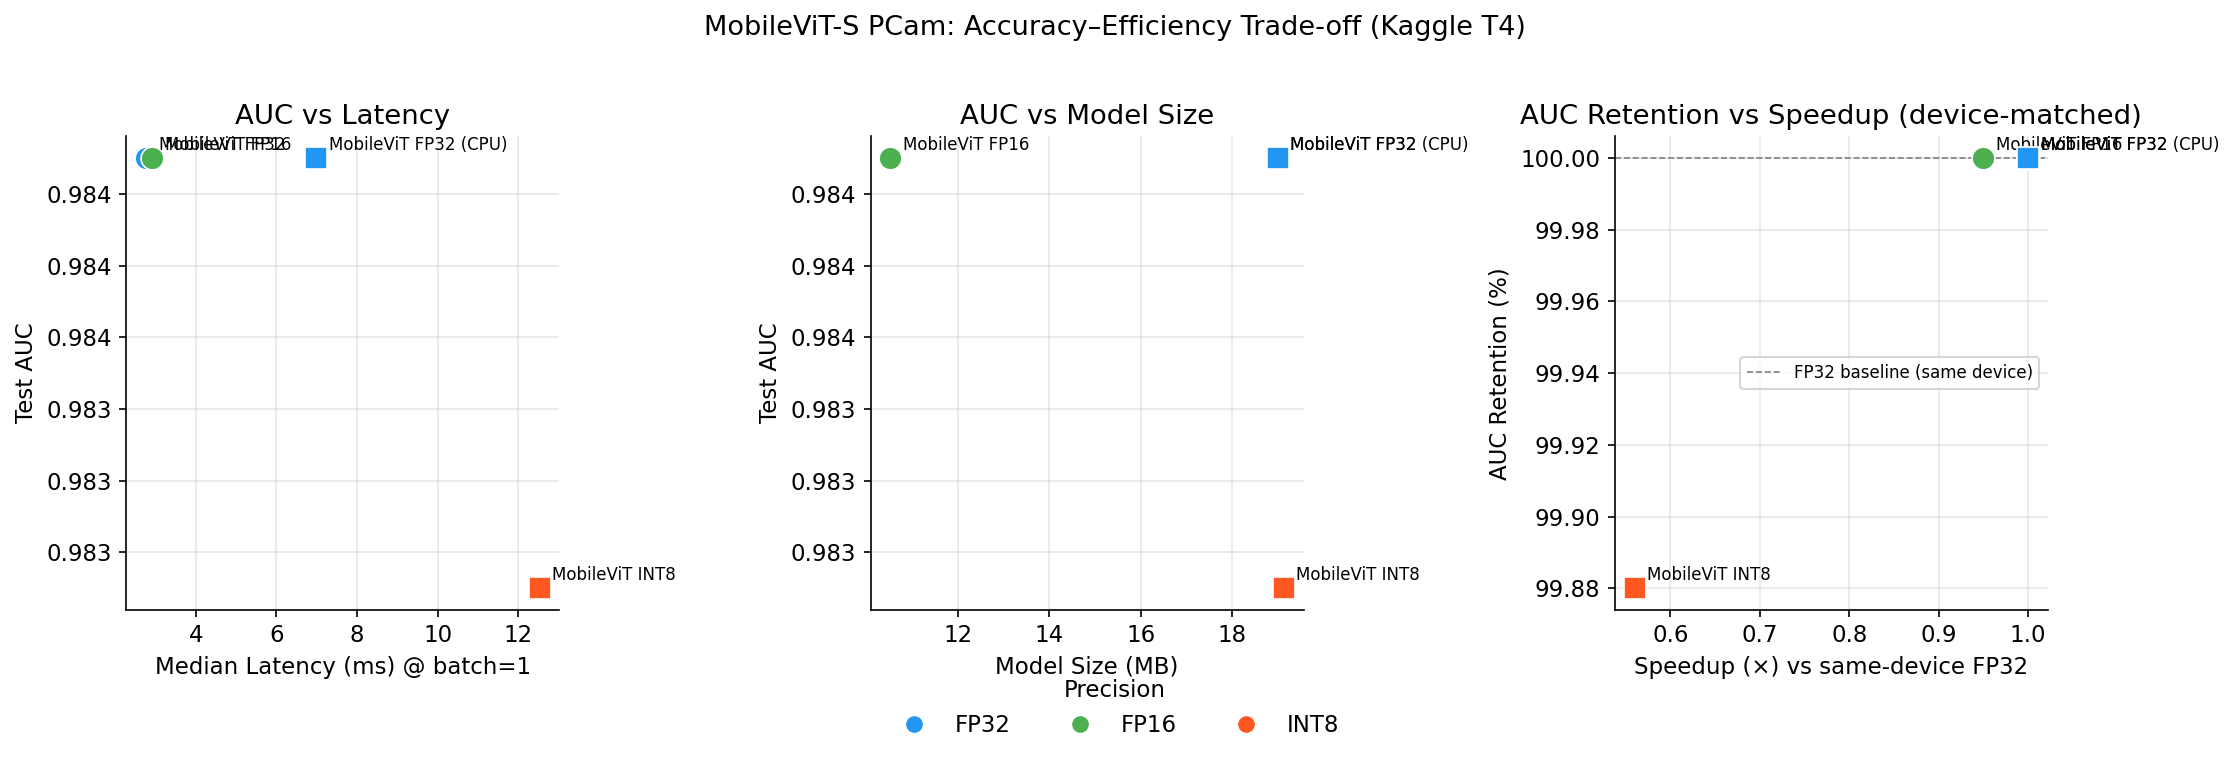

✓ Pareto plots saved to /kaggle/working/edge_opt_results/


In [22]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'font.family':   'DejaVu Sans',
    'font.size':     11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'figure.dpi':         150,
})

# Filter to GPU-inference rows for latency plots (or CPU if no GPU)
df_plot = df_results[df_results['Device'].isin(['T4 GPU', 'CPU'])].copy()

COLORS = {'FP32': '#2196F3', 'FP16': '#4CAF50', 'INT8': '#FF5722'}
MARKERS = {'T4 GPU': 'o', 'CPU': 's'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Plot 1: AUC vs Latency ───────────────────────────────────────────────────
ax = axes[0]
for _, row in df_plot.dropna(subset=['Median_ms']).iterrows():
    ax.scatter(row['Median_ms'], row['Test_AUC'],
               color=COLORS.get(row['Precision'], 'grey'),
               marker=MARKERS.get(row['Device'], 'o'),
               s=120, zorder=5, edgecolors='white', linewidths=0.8)
    ax.annotate(row['Variant'], (row['Median_ms'], row['Test_AUC']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_xlabel('Median Latency (ms) @ batch=1')
ax.set_ylabel('Test AUC')
ax.set_title('AUC vs Latency')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# ── Plot 2: AUC vs Model Size ────────────────────────────────────────────────
ax = axes[1]
for _, row in df_plot.iterrows():
    ax.scatter(row['Size_MB'], row['Test_AUC'],
               color=COLORS.get(row['Precision'], 'grey'),
               marker=MARKERS.get(row['Device'], 'o'),
               s=120, zorder=5, edgecolors='white', linewidths=0.8)
    ax.annotate(row['Variant'], (row['Size_MB'], row['Test_AUC']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_xlabel('Model Size (MB)')
ax.set_ylabel('Test AUC')
ax.set_title('AUC vs Model Size')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# ── Plot 3: AUC Retention vs Speedup ────────────────────────────────────────
# BUGFIX: previously plotted against Speedup_x, a single GPU-FP32-relative
# column that made every CPU row (INT8, FP32 CPU) look far slower than it
# really is relative to its own device. Speedup_x_same_device compares each
# point to the FP32 baseline on its own device, so the plot isolates the
# precision effect instead of mixing it with a device effect.
ax = axes[2]
for _, row in df_plot.dropna(subset=['Speedup_x_same_device']).iterrows():
    ax.scatter(row['Speedup_x_same_device'], row['AUC_Retention_pct'],
               color=COLORS.get(row['Precision'], 'grey'),
               marker=MARKERS.get(row['Device'], 'o'),
               s=120, zorder=5, edgecolors='white', linewidths=0.8)
    ax.annotate(row['Variant'], (row['Speedup_x_same_device'], row['AUC_Retention_pct']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.axhline(100.0, color='grey', linestyle='--', linewidth=0.8, label='FP32 baseline (same device)')
ax.set_xlabel('Speedup (×) vs same-device FP32')
ax.set_ylabel('AUC Retention (%)')
ax.set_title('AUC Retention vs Speedup (device-matched)')
ax.legend(fontsize=8)

# Legend for precision
from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
                          markersize=9, label=p) for p, c in COLORS.items()]
fig.legend(handles=legend_handles, title='Precision', loc='lower center',
           ncol=3, bbox_to_anchor=(0.5, -0.08), frameon=False)

fig.suptitle('MobileViT-S PCam: Accuracy–Efficiency Trade-off (Kaggle T4)', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'pareto_analysis.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(OUT_DIR, 'pareto_analysis.png'), bbox_inches='tight')
plt.show()
print(f'✓ Pareto plots saved to {OUT_DIR}/')

In [23]:
# ── Paper-ready Tables ────────────────────────────────────────────────────────
print('=' * 80)
print('TABLE 1 — Model Accuracy')
print('=' * 80)
t1_cols = ['Variant', 'Precision', 'Test_AUC', 'AUC_CI_low', 'AUC_CI_high', 'AUC_Retention_pct', 'Delta_AUC',
           'F1_fixed_thresh_0.5', 'F1_calibrated', 'Calib_Threshold']
print(df_results[t1_cols].to_string(index=False))
print('\n(AUC_CI_low/high: 95% bootstrap CI on Test_AUC, 1000 resamples.)')

print()
print()
print('=' * 80)
print('TABLE 1b — Sensitivity / Specificity (Test set)')
print('=' * 80)
t1b_cols = ['Variant', 'Precision', 'Sensitivity_fixed_0.5', 'Specificity_fixed_0.5',
            'Sensitivity_calibrated', 'Specificity_calibrated']
print(df_results[t1b_cols].to_string(index=False))
print()
print('Sensitivity = recall on tumor-positive class (low = missed-tumor risk).')
print('Specificity = recall on normal-negative class (low = false-alarm risk).')

print('=' * 80)
print('TABLE 2 — Computational Efficiency')
print('=' * 80)
t2_cols = ['Variant', 'Precision', 'Device', 'Size_MB', 'Compression_x', 'Median_ms',
           'p95_ms', 'FPS', 'Speedup_x_same_device', 'Speedup_x_vs_GPU_FP32']
print(df_results[t2_cols].to_string(index=False))
print()
print('Speedup_x_same_device: precision effect only (matched device baseline).')
print('Speedup_x_vs_GPU_FP32: cross-device deployment picture (CPU rows will')
print('                       always look slow here regardless of precision).')

print()
print('=' * 80)
print('ARCHITECTURE REFERENCE')
print('=' * 80)
print(f'  Backbone:    {CONFIG["BACKBONE"]}')
print(f'  Input size:  {CONFIG["IMG_SIZE"]}x{CONFIG["IMG_SIZE"]} px')
print(f'  Parameters:  {total_params:,}')
print(f'  MACs:        {total_macs / 1e6:.1f} M')
print(f'  FP32 size:   {fp32_size_mb:.2f} MB')


TABLE 1 — Model Accuracy
             Variant Precision  Test_AUC  AUC_CI_low  AUC_CI_high  AUC_Retention_pct  Delta_AUC  F1_fixed_thresh_0.5  F1_calibrated  Calib_Threshold
      MobileViT FP32      FP32    0.9841      0.9759       0.9908             100.00     0.0000               0.9517         0.9588           0.4138
      MobileViT FP16      FP16    0.9841      0.9758       0.9907             100.00    -0.0000               0.9531         0.9588           0.4187
      MobileViT INT8      INT8    0.9829      0.9744       0.9902              99.88    -0.0012               0.9481         0.9516           0.3350
MobileViT FP32 (CPU)      FP32    0.9841      0.9759       0.9908             100.00     0.0000               0.9517         0.9588           0.4138

(AUC_CI_low/high: 95% bootstrap CI on Test_AUC, 1000 resamples.)


TABLE 1b — Sensitivity / Specificity (Test set)
             Variant Precision  Sensitivity_fixed_0.5  Specificity_fixed_0.5  Sensitivity_calibrated  Specificity_

In [24]:
# ── Final summary & best operating point ─────────────────────────────────────
# BUGFIX: previously scored by AUC_Retention_pct * Speedup_x, where Speedup_x
# was the device-confounded column (bug #3). Because that metric made GPU
# look no faster than CPU (bug #2) and made INT8/CPU look artificially slow
# vs a GPU baseline it never ran on, the score spuriously favored the
# unoptimized FP32 (CPU) row. Scoring on Speedup_x_same_device removes both
# confounds so the ranking reflects real precision/device trade-offs.
best_auc_ret = df_results.dropna(subset=['Speedup_x_same_device']).copy()
best_auc_ret['score'] = best_auc_ret['AUC_Retention_pct'] * best_auc_ret['Speedup_x_same_device']
best_row = best_auc_ret.loc[best_auc_ret['score'].idxmax()]

print('\n' + '=' * 60)
print('OPTIMAL OPERATING POINT')
print('=' * 60)
print(f'  Variant:         {best_row["Variant"]}')
print(f'  Test AUC:        {best_row["Test_AUC"]:.4f}')
print(f'  AUC Retention:   {best_row["AUC_Retention_pct"]:.2f}%')
print(f'  F1 (calibrated): {best_row["F1_calibrated"]:.4f}  (fixed-0.5: {best_row["F1_fixed_thresh_0.5"]:.4f})')
print(f'  Speedup (same-device baseline): {best_row["Speedup_x_same_device"]}x')
print(f'  Size:            {best_row["Size_MB"]} MB ({best_row["Compression_x"]}x smaller)')
print(f'  Median Latency:  {best_row["Median_ms"]} ms @ batch=1')
print()
print('NOTE: All measurements on Kaggle NVIDIA T4 GPU (GPU variants) and')
print('      Kaggle CPU (INT8 variant). Reported as resource-constrained')
print('      computational efficiency — not direct edge-device deployment.')
print('      GPU latency is IOBinding-based compute-only timing (bug #2 fix);')
print('      speedup is scored against a same-device FP32 baseline (bug #3 fix).')



OPTIMAL OPERATING POINT
  Variant:         MobileViT FP32
  Test AUC:        0.9841
  AUC Retention:   100.00%
  F1 (calibrated): 0.9588  (fixed-0.5: 0.9517)
  Speedup (same-device baseline): 1.0x
  Size:            19.01 MB (1.0x smaller)
  Median Latency:  2.771 ms @ batch=1

NOTE: All measurements on Kaggle NVIDIA T4 GPU (GPU variants) and
      Kaggle CPU (INT8 variant). Reported as resource-constrained
      computational efficiency — not direct edge-device deployment.
      GPU latency is IOBinding-based compute-only timing (bug #2 fix);
      speedup is scored against a same-device FP32 baseline (bug #3 fix).


## Conservative INT8 CPU Benchmark


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CPU Benchmark — deployment-oriented, batch=1
#
# The previous results showed poor INT8 scaling at high thread counts.
# Use 2 intra-op threads / 1 inter-op thread as the default comparison point.
# ─────────────────────────────────────────────────────────────────────────────

def benchmark_onnx_cpu(
    onnx_path,
    input_np_fp32,
    warmup=30,
    iters=150,
    intra_threads=2,
):
    sess_opts = ort.SessionOptions()
    sess_opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    sess_opts.intra_op_num_threads = intra_threads
    sess_opts.inter_op_num_threads = 1
    sess_opts.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL
    sess_opts.log_severity_level = 3

    sess = ort.InferenceSession(
        onnx_path,
        sess_options=sess_opts,
        providers=["CPUExecutionProvider"],
    )

    input_name = sess.get_inputs()[0].name

    for _ in range(warmup):
        sess.run(None, {input_name: input_np_fp32})

    times_ms = []
    for _ in range(iters):
        t0 = time.perf_counter()
        sess.run(None, {input_name: input_np_fp32})
        times_ms.append((time.perf_counter() - t0) * 1000.0)

    times_ms = np.asarray(times_ms)

    return {
        "median_ms": float(np.median(times_ms)),
        "p95_ms": float(np.percentile(times_ms, 95)),
        "p99_ms": float(np.percentile(times_ms, 99)),
        "throughput_fps": float(1000.0 / np.median(times_ms)),
        "all_times_ms": times_ms,
    }


print("ORT version:", ort.__version__)
print("Available providers:", ort.get_available_providers())
print()

bench_fp32_cpu = benchmark_onnx_cpu(
    ONNX_FP32,
    bench_img_np,
    warmup=30,
    iters=150,
    intra_threads=2,
)

bench_int8_cpu = benchmark_onnx_cpu(
    ONNX_INT8,
    bench_img_np,
    warmup=30,
    iters=150,
    intra_threads=2,
)

print("=" * 80)
print("CPU LATENCY")
print("=" * 80)
print(
    f"FP32 : {bench_fp32_cpu['median_ms']:.3f} ms median | "
    f"{bench_fp32_cpu['p95_ms']:.3f} ms p95 | "
    f"{bench_fp32_cpu['throughput_fps']:.1f} FPS"
)
print(
    f"INT8 : {bench_int8_cpu['median_ms']:.3f} ms median | "
    f"{bench_int8_cpu['p95_ms']:.3f} ms p95 | "
    f"{bench_int8_cpu['throughput_fps']:.1f} FPS"
)
print(
    f"INT8 / FP32 latency ratio: "
    f"{bench_int8_cpu['median_ms'] / bench_fp32_cpu['median_ms']:.2f}x"
)


ORT version: 1.26.0
Available providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']

CPU LATENCY
FP32 : 6.997 ms median | 11.121 ms p95 | 142.9 FPS
INT8 : 9.983 ms median | 10.701 ms p95 | 100.2 FPS
INT8 / FP32 latency ratio: 1.43x


## Precision Ablation — Full Candidate Comparison

The mixed-precision INT8 selection above picks a winner (`selected_candidate`) using validation AUC only, then re-quantizes just that winner with the full calibration set — which is correct methodology, but it also means the *losing* candidate's numbers never get reported anywhere. A reviewer asking "compared with what?" about the mixed-precision strategy itself needs to see **both** candidates side by side, not just the one that won.

This table reports, for every INT8 Conv-quantization candidate plus the final re-quantized selection and an FP32 CPU reference:
- how many Conv nodes were quantized,
- how many calibration images were used (the two screening candidates used a smaller `SCREEN_CALIB_N`; the final selected model was re-quantized with the full `CONFIG['CALIB_IMAGES']` set — these are **not** apples-to-apples on calibration size, which the table makes explicit),
- validation AUC (the quantity actually used for selection),
- test AUC with a 95% bootstrap CI (reported for completeness; **not** used for selection),
- CPU latency and model size.

Test-set numbers here are diagnostic/reporting only — the selection decision earlier in this notebook was and remains validation-only.

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Full precision-ablation table: report ALL INT8 candidates, not just the winner
#
# candidate_paths / candidate_specs / candidate_val_scores / selected_candidate
# were all set earlier during candidate selection. Selection there used
# validation AUC only; nothing below changes that decision -- this cell adds
# test-set numbers, latency, and size for every candidate purely for
# transparent ablation reporting.
# ─────────────────────────────────────────────────────────────────────────────

ablation_rows = []

for candidate_name, candidate_path in candidate_paths.items():
    val_r  = evaluate_onnx(candidate_path, val_loader,  use_gpu=False, desc=f"Ablation {candidate_name} val")
    test_r = evaluate_onnx(candidate_path, test_loader, use_gpu=False, desc=f"Ablation {candidate_name} test")
    bench_r = benchmark_onnx_cpu(candidate_path, bench_img_np, warmup=30, iters=150, intra_threads=2)
    _, ci_lo, ci_hi = bootstrap_auc_ci(test_r['labels'], test_r['probs'], n_boot=1000, seed=0)

    ablation_rows.append({
        'Candidate':        candidate_name,
        'Selected':         (candidate_name == selected_candidate),
        'Conv_Nodes_Quantized': len(candidate_specs[candidate_name]),
        'Calib_Images':     SCREEN_CALIB_N,
        'Size_MB':          round(os.path.getsize(candidate_path) / (1024 ** 2), 2),
        'Val_AUC':          round(val_r['auc'], 4),
        'Test_AUC':         round(test_r['auc'], 4),
        'Test_AUC_CI_low':  round(ci_lo, 4) if not np.isnan(ci_lo) else None,
        'Test_AUC_CI_high': round(ci_hi, 4) if not np.isnan(ci_hi) else None,
        'Test_F1':          round(test_r['f1'], 4),
        'Median_ms':        round(bench_r['median_ms'], 3),
        'p95_ms':           round(bench_r['p95_ms'], 3),
    })

# Final re-quantized selection (full calibration set) -- reuses the accuracy
# numbers already computed earlier (onnx_int8_val / onnx_int8_test) and the
# latency already computed just above in this section (bench_int8_cpu), so
# it is not re-run.
_, final_ci_lo, final_ci_hi = bootstrap_auc_ci(
    onnx_int8_test['labels'], onnx_int8_test['probs'], n_boot=1000, seed=0
)
ablation_rows.append({
    'Candidate':        f'{selected_candidate} (FINAL, full calib)',
    'Selected':         True,
    'Conv_Nodes_Quantized': len(candidate_specs[selected_candidate]),
    'Calib_Images':     len(calib_indices),
    'Size_MB':          round(int8_size_mb, 2),
    'Val_AUC':          round(onnx_int8_val['auc'], 4),
    'Test_AUC':         round(onnx_int8_test['auc'], 4),
    'Test_AUC_CI_low':  round(final_ci_lo, 4) if not np.isnan(final_ci_lo) else None,
    'Test_AUC_CI_high': round(final_ci_hi, 4) if not np.isnan(final_ci_hi) else None,
    'Test_F1':          round(onnx_int8_test['f1'], 4),
    'Median_ms':        round(bench_int8_cpu['median_ms'], 3),
    'p95_ms':           round(bench_int8_cpu['p95_ms'], 3),
})

# FP32 CPU reference row for scale (reuses bench_fp32_cpu computed just above).
ablation_rows.append({
    'Candidate':        'FP32 (no quantization, CPU reference)',
    'Selected':         False,
    'Conv_Nodes_Quantized': 0,
    'Calib_Images':     None,
    'Size_MB':          round(fp32_size_mb, 2),
    'Val_AUC':          round(onnx_fp32_val['auc'], 4),
    'Test_AUC':         round(onnx_fp32_test['auc'], 4),
    'Test_AUC_CI_low':  None,
    'Test_AUC_CI_high': None,
    'Test_F1':          round(onnx_fp32_test['f1'], 4),
    'Median_ms':        round(bench_fp32_cpu['median_ms'], 3),
    'p95_ms':           round(bench_fp32_cpu['p95_ms'], 3),
})

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(os.path.join(OUT_DIR, 'mixed_precision_ablation_table.csv'), index=False)

print("=" * 100)
print("TABLE — MIXED-PRECISION INT8 CANDIDATE ABLATION")
print("=" * 100)
print(ablation_df.to_string(index=False))
print(f"\n\u2713 Saved to {OUT_DIR}/mixed_precision_ablation_table.csv")
print("\nNOTE: the two screening candidates (SAFE_CONV, STEM_CONV) were quantized with")
print("      only SCREEN_CALIB_N calibration images for fast comparison; the FINAL row")
print("      re-quantizes the SELECTED candidate with the full calibration set -- sizes")
print("      and AUCs are not directly comparable to the screening rows on that axis.")
print("NOTE: selection used Val_AUC only, decided earlier in the notebook. Test_AUC and")
print("      its bootstrap CI are reported here for transparency, not for selection.")


Ablation SAFE_CONV val:   0%|          | 0/3 [00:00<?, ?it/s]

Ablation SAFE_CONV test:   0%|          | 0/3 [00:00<?, ?it/s]

Ablation STEM_CONV val:   0%|          | 0/3 [00:00<?, ?it/s]

Ablation STEM_CONV test:   0%|          | 0/3 [00:00<?, ?it/s]

TABLE — MIXED-PRECISION INT8 CANDIDATE ABLATION
                            Candidate  Selected  Conv_Nodes_Quantized  Calib_Images  Size_MB  Val_AUC  Test_AUC  Test_AUC_CI_low  Test_AUC_CI_high  Test_F1  Median_ms  p95_ms
                            SAFE_CONV      True                    10         300.0    19.14   0.9821    0.9821           0.9736            0.9897   0.9479     10.262  10.945
                            STEM_CONV     False                    13         300.0    19.68   0.8164    0.8164           0.7864            0.8497   0.7204      8.845   9.692
        SAFE_CONV (FINAL, full calib)      True                    10         733.0    19.14   0.9829    0.9829           0.9744            0.9902   0.9481      9.983  10.701
FP32 (no quantization, CPU reference)     False                     0           NaN    19.01   0.9841    0.9841              NaN               NaN   0.9517      6.997  11.121

✓ Saved to /kaggle/working/edge_opt_results/mixed_precision_ablation_table.c

## INT8 Graph Sanity Check


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# SECOND-GEN INT8 GRAPH + EXECUTION-PROVIDER SANITY CHECK
# ─────────────────────────────────────────────────────────────────────────────

import onnx
from collections import Counter

model = onnx.load(ONNX_INT8)
op_counts = Counter(node.op_type for node in model.graph.node)

print("=" * 80)
print("SECOND-GENERATION MIXED-PRECISION INT8 GRAPH")
print("=" * 80)
print("Selected candidate:", selected_candidate)
print("Quantized Conv nodes:", len(selected_nodes))

for op, count in op_counts.most_common():
    print(f"{op:<30} {count}")

print("\nQuantization operators:")
for op in [
    "QuantizeLinear", "DequantizeLinear", "QLinearConv", "ConvInteger",
    "MatMulInteger", "QLinearMatMul"
]:
    print(f"{op:<20}: {op_counts.get(op, 0)}")

# Verify the final graph can initialize on the intended CPU EP.
try:
    cpu_opts = ort.SessionOptions()
    cpu_opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    cpu_opts.log_severity_level = 3
    cpu_sess = ort.InferenceSession(
        ONNX_INT8,
        sess_options=cpu_opts,
        providers=["CPUExecutionProvider"],
    )
    print("\n✓ CPUExecutionProvider session initialized")
    print("  Providers:", cpu_sess.get_providers())
    print("  Input:", cpu_sess.get_inputs()[0].name, cpu_sess.get_inputs()[0].shape)
except Exception as e:
    print("\n✗ CPUExecutionProvider initialization failed:", type(e).__name__, e)

print("\nNOTE: QDQ nodes are expected in a QDQ-format graph. Their presence alone")
print("does NOT prove that execution is FP32; the actual execution provider/kernel")
print("selection determines whether quantized Conv kernels are used.")


SECOND-GENERATION MIXED-PRECISION INT8 GRAPH
Selected candidate: SAFE_CONV
Quantized Conv nodes: 10
Mul                            59
Reshape                        59
Add                            56
MatMul                         54
Slice                          54
Concat                         43
Transpose                      39
DequantizeLinear               37
Conv                           35
Sigmoid                        34
Squeeze                        28
LayerNormalization             21
QuantizeLinear                 20
Shape                          12
Softmax                        9
Resize                         2
ReduceMean                     1
Gemm                           1

Quantization operators:
QuantizeLinear      : 20
DequantizeLinear    : 37
QLinearConv         : 0
ConvInteger         : 0
MatMulInteger       : 0
QLinearMatMul       : 0

✓ CPUExecutionProvider session initialized
  Providers: ['CPUExecutionProvider']
  Input: input ['batch', 3, 96, 96]

NO

## Second-Generation Mixed-Precision INT8 Evaluation


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Accuracy Evaluation + Validation-Only Threshold Calibration
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 80)
print("SECOND-GENERATION MIXED-PRECISION INT8 ACCURACY")
print("=" * 80)

onnx_int8_val = evaluate_onnx(
    ONNX_INT8,
    val_loader,
    use_gpu=False,
    desc="Mixed INT8 Val",
)

onnx_int8_test = evaluate_onnx(
    ONNX_INT8,
    test_loader,
    use_gpu=False,
    desc="Mixed INT8 Test",
)

print("\nRaw metrics:")
print(f"Val  AUC: {onnx_int8_val['auc']:.4f}")
print(f"Test AUC: {onnx_int8_test['auc']:.4f}")

# Calibrate threshold on validation only.
thresh, val_f1_at_thresh = best_f1_threshold(
    onnx_int8_val["probs"],
    onnx_int8_val["labels"],
)

test_preds_cal = (
    onnx_int8_test["probs"] >= thresh
).astype(int)

test_f1_cal = f1_score(
    onnx_int8_test["labels"],
    test_preds_cal,
)

test_sens_cal, test_spec_cal = sens_spec(
    onnx_int8_test["labels"], onnx_int8_test["probs"], thresh
)



print("\nCalibrated metrics:")
print(f"Threshold       : {thresh:.6f}")
print(f"Val F1          : {val_f1_at_thresh:.4f}")
print(f"Test F1         : {test_f1_cal:.4f}")
print(f"Test sensitivity: {test_sens_cal:.4f}")
print(f"Test specificity: {test_spec_cal:.4f}")

if "auc" in onnx_int8_test:
    auc_ret = onnx_int8_test["auc"] / onnx_fp32_test["auc"] * 100 if "onnx_fp32_test" in globals() else None
    if auc_ret is not None:
        print(f"AUC retention    : {auc_ret:.2f}%")
    else:
        print("AUC retention    : N/A (FP32 test results not available)")


SECOND-GENERATION MIXED-PRECISION INT8 ACCURACY


Mixed INT8 Val:   0%|          | 0/3 [00:00<?, ?it/s]

Mixed INT8 Test:   0%|          | 0/3 [00:00<?, ?it/s]


Raw metrics:
Val  AUC: 0.9829
Test AUC: 0.9829

Calibrated metrics:
Threshold       : 0.335025
Val F1          : 0.9516
Test F1         : 0.9516
Test sensitivity: 0.9785
Test specificity: 0.9197
AUC retention    : 99.88%


## Final Deployment Summary


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# Final Deployment Summary — Second-Generation Mixed Precision
# ─────────────────────────────────────────────────────────────────────────────

size_mb = os.path.getsize(ONNX_INT8) / (1024 ** 2)
compression = fp32_size_mb / size_mb
lat_ratio = bench_int8_cpu["median_ms"] / bench_fp32_cpu["median_ms"]

print("=" * 80)
print("DEPLOYMENT SUMMARY — MIXED-PRECISION INT8")
print("=" * 80)
print(f"Model size       : {size_mb:.2f} MB")
print(f"Compression      : {compression:.2f}x")
print(f"FP32 CPU median  : {bench_fp32_cpu['median_ms']:.3f} ms")
print(f"INT8 CPU median  : {bench_int8_cpu['median_ms']:.3f} ms")
print(f"Latency ratio    : {lat_ratio:.2f}x")
print(f"Test AUC         : {onnx_int8_test['auc']:.4f}")
print(f"Calibrated F1    : {test_f1_cal:.4f}")
print(f"Calibrated sens. : {test_sens_cal:.4f}")

print("\nInterpretation:")
if onnx_int8_test["auc"] >= 0.94:
    print("✓ Accuracy is substantially closer to FP32; mixed-precision INT8 is a strong candidate.")
elif onnx_int8_test["auc"] >= 0.92:
    print("△ Accuracy is improved but still below the FP32 target; review the deployment requirement.")
else:
    print("✗ PTQ accuracy remains materially degraded; the next step is QAT or a more selective FP32/INT8 partition.")

if lat_ratio < 1.0:
    print("✓ INT8 is faster than FP32 in this CPU configuration.")
else:
    print("△ INT8 is not faster than FP32 in this CPU configuration; backend/kernel optimization remains a separate issue.")


DEPLOYMENT SUMMARY — MIXED-PRECISION INT8
Model size       : 19.14 MB
Compression      : 0.99x
FP32 CPU median  : 6.997 ms
INT8 CPU median  : 9.983 ms
Latency ratio    : 1.43x
Test AUC         : 0.9829
Calibrated F1    : 0.9516
Calibrated sens. : 0.9785

Interpretation:
✓ Accuracy is substantially closer to FP32; mixed-precision INT8 is a strong candidate.
△ INT8 is not faster than FP32 in this CPU configuration; backend/kernel optimization remains a separate issue.


## Fourth-Generation: Conv+MatMul Mixed Precision — Closing the INT8 Latency Gap

The second-generation INT8 above (`ONNX_INT8`, Step C2) deliberately keeps `MatMul` in
`SENSITIVE_OPS` and only quantizes a subset of `Conv` nodes. That was the right call for
accuracy, but it has a latency consequence worth making explicit: this backbone has 35 `Conv`
nodes and 54 `MatMul` nodes (the attention/FFN layers), so a Conv-only quantization leaves the
majority of the model's compute in FP32 while still paying the QuantizeLinear/DequantizeLinear
conversion cost at every quantized boundary. That's the most likely reason the Conservative INT8
CPU Benchmark section above shows INT8 at or slower than FP32 rather than faster.

This section runs a second axis of the same validation-only screening methodology already used
for `SAFE_CONV` / `STEM_CONV`, extended to `MatMul`:

1. Classify `MatMul` nodes by graph proximity to `Softmax` (2-hop BFS) — nodes near a Softmax are
   the attention-score matmuls (`QK^T` and `softmax(QK^T) @ V`), which are the ones a ViT
   quantization literature review would flag as precision-sensitive. Nodes further away are
   mostly FFN/projection linear layers, which tend to quantize much more safely.
2. Quantize `Conv` (existing `safe_conv_nodes`) **and** the "safe" `MatMul` set together, and
   compare **QDQ format** (matches the existing pipeline's format, isolates the op-coverage
   effect) against **QOperator format** (fuses into `QLinearConv`/`QLinearMatMul` kernels directly
   — isolates the format effect on CPU latency).
3. Selection is validation-AUC-only, same rule as Step C2, then the winner is re-quantized with
   the full calibration set and benchmarked with the same thread-matched harness (`intra_threads=2`)
   used in the Conservative INT8 CPU Benchmark section, so the comparison to `bench_fp32_cpu` is
   apples-to-apples.


In [30]:
# ── Step D1: Classify MatMul nodes by proximity to Softmax ──────────────────
# Same spirit as the SAFE_CONV / STEM_CONV split in Step C2, extended to MatMul.
# MatMul nodes within 2 hops of a Softmax node are treated as attention-score-
# sensitive and left FP32; the rest (mostly FFN/projection linear layers) are
# quantization candidates.

from collections import defaultdict, Counter

gen4_model = onnx.load(ONNX_FP32_PREP)
gen4_nodes = list(gen4_model.graph.node)

gen4_producer_of = {}
for n in gen4_nodes:
    for out in n.output:
        gen4_producer_of[out] = n

gen4_consumers = defaultdict(list)
for n in gen4_nodes:
    for inp in n.input:
        gen4_consumers[inp].append(n)

def _gen4_neighbors(n):
    out = []
    for inp in n.input:
        p = gen4_producer_of.get(inp)
        if p is not None:
            out.append(p)
    for o in n.output:
        out.extend(gen4_consumers.get(o, []))
    return out

softmax_nodes = [n for n in gen4_nodes if n.op_type == "Softmax"]
sensitive_ids = set()
frontier = list(softmax_nodes)
visited = set(id(n) for n in frontier)
for _hop in range(2):  # 2-hop BFS from every Softmax node
    nxt = []
    for n in frontier:
        for nb in _gen4_neighbors(n):
            if id(nb) not in visited:
                visited.add(id(nb))
                nxt.append(nb)
    frontier = nxt
    sensitive_ids.update(id(n) for n in frontier if n.op_type == "MatMul")

matmul_nodes = [n for n in gen4_nodes if n.op_type == "MatMul"]
safe_matmul_nodes = [n.name for n in matmul_nodes if id(n) not in sensitive_ids]
sensitive_matmul_nodes = [n.name for n in matmul_nodes if id(n) in sensitive_ids]

print(f"Total MatMul nodes      : {len(matmul_nodes)}")
print(f"Sensitive (near Softmax): {len(sensitive_matmul_nodes)}  (kept FP32)")
print(f"Safe (FFN/projection)   : {len(safe_matmul_nodes)}  (quantization candidates)")

if "safe_conv_nodes" not in globals():
    raise RuntimeError(
        "safe_conv_nodes is not defined -- run the Step C2 mixed-precision cell first "
        "(this section builds on its Conv classification)."
    )
print(f"\nReusing safe_conv_nodes from Step C2: {len(safe_conv_nodes)} Conv nodes")


Total MatMul nodes      : 54
Sensitive (near Softmax): 18  (kept FP32)
Safe (FFN/projection)   : 36  (quantization candidates)

Reusing safe_conv_nodes from Step C2: 10 Conv nodes


In [31]:
# ── Step D2: Quantize Conv+MatMul candidates (screen calibration set) ───────
# Two candidates, same node set (safe_conv_nodes + safe_matmul_nodes), to
# separate the op-coverage effect from the format effect:
#   CONV_MATMUL_QDQ       -- QDQ format (matches Step C2's format exactly)
#   CONV_MATMUL_QOPERATOR -- QOperator format (fuses to QLinearConv/QLinearMatMul,
#                             the change actually expected to move CPU latency)

gen4_candidate_dir = os.path.join(OUT_DIR, "gen4_conv_matmul_candidates")
os.makedirs(gen4_candidate_dir, exist_ok=True)

gen4_node_set = list(safe_conv_nodes) + list(safe_matmul_nodes)

def quantize_nodes_v2(node_names, output_path, calibration_indices, op_types,
                       quant_format, method=CalibrationMethod.MinMax):
    '''Like Step C2's quantize_nodes(), generalized to arbitrary op_types_to_quantize
    and quant_format so it can cover Conv+MatMul and both QDQ/QOperator without
    touching the original helper (which downstream cells 29/49/53/55 still depend on).'''
    if os.path.exists(output_path):
        os.remove(output_path)
    reader = make_calib_reader(calibration_indices)
    quantize_static(
        model_input=ONNX_FP32_PREP,
        model_output=output_path,
        calibration_data_reader=reader,
        weight_type=QuantType.QInt8,
        activation_type=QuantType.QUInt8,
        quant_format=quant_format,
        per_channel=False,
        calibrate_method=method,
        nodes_to_quantize=list(node_names),
        op_types_to_quantize=op_types,
    )
    if not os.path.exists(output_path):
        raise RuntimeError(f"Quantization failed to create {output_path}")

gen4_candidate_specs = {
    "CONV_MATMUL_QDQ":       (gen4_node_set, QuantFormat.QDQ),
    "CONV_MATMUL_QOPERATOR": (gen4_node_set, QuantFormat.QOperator),
}

gen4_candidate_paths = {}
for cand_name, (node_names, fmt) in gen4_candidate_specs.items():
    path = os.path.join(gen4_candidate_dir, f"mobilevit_{cand_name.lower()}_screen.onnx")
    print(f"\nQuantizing {cand_name}: {len(node_names)} nodes "
          f"({len(safe_conv_nodes)} Conv + {len(safe_matmul_nodes)} MatMul), format={fmt}")
    t0 = time.time()
    quantize_nodes_v2(node_names, path, screen_indices, op_types=["Conv", "MatMul"], quant_format=fmt)
    gen4_candidate_paths[cand_name] = path
    print(f"  \u2713 {cand_name}: {time.time() - t0:.1f}s | {os.path.getsize(path)/(1024**2):.2f} MB")



Quantizing CONV_MATMUL_QDQ: 46 nodes (10 Conv + 36 MatMul), format=QDQ
  ✓ CONV_MATMUL_QDQ: 44.3s | 10.90 MB

Quantizing CONV_MATMUL_QOPERATOR: 46 nodes (10 Conv + 36 MatMul), format=QOperator
  ✓ CONV_MATMUL_QOPERATOR: 44.5s | 10.77 MB


In [32]:
# ── Step D3: Validation-only selection + full re-quantization of the winner ─
# Same rule as Step C2: select on validation AUC only, never on test.

print("=" * 80)
print("GEN-4 (CONV+MATMUL) CANDIDATE SELECTION -- VALIDATION ONLY")
print("=" * 80)

gen4_val_scores = {}
for cand_name, cand_path in gen4_candidate_paths.items():
    try:
        r = evaluate_onnx(cand_path, val_loader, use_gpu=False, desc=f"Val {cand_name}")
        gen4_val_scores[cand_name] = r["auc"]
        print(f"{cand_name:<22} validation AUC: {r['auc']:.4f}")
    except Exception as e:
        gen4_val_scores[cand_name] = -np.inf
        print(f"{cand_name:<22} FAILED: {type(e).__name__}: {e}")

# Also compare against the existing Step C2 first-generation INT8 (Conv-only),
# already evaluated earlier as onnx_int8_val.
print(f"{'CONV_ONLY (Step C2)':<22} validation AUC: {onnx_int8_val['auc']:.4f}  (reference, already selected)")

if not any(np.isfinite(v) for v in gen4_val_scores.values()):
    raise RuntimeError("All Gen-4 Conv+MatMul candidates failed validation.")

gen4_selected = max(gen4_val_scores, key=gen4_val_scores.get)
gen4_selected_nodes, gen4_selected_fmt = gen4_candidate_specs[gen4_selected]
print(f"\n\u2713 Selected Gen-4 candidate: {gen4_selected}")
print(f"  Screening validation AUC: {gen4_val_scores[gen4_selected]:.4f}")

delta_vs_conv_only = gen4_val_scores[gen4_selected] - onnx_int8_val["auc"]
print(f"  Delta vs. Step C2 Conv-only (val AUC): {delta_vs_conv_only:+.4f}")

# Re-quantize the winner with the FULL calibration set, same as Step C2.
ONNX_INT8_GEN4 = os.path.join(OUT_DIR, "mobilevit_int8_conv_matmul.onnx")
print(f"\nRe-quantizing {gen4_selected} with {len(calib_indices)} calibration images...")
t0 = time.time()
quantize_nodes_v2(gen4_selected_nodes, ONNX_INT8_GEN4, calib_indices,
                   op_types=["Conv", "MatMul"], quant_format=gen4_selected_fmt)
print(f"\u2713 Final Gen-4 INT8 created in {time.time() - t0:.1f}s")

gen4_size_mb = os.path.getsize(ONNX_INT8_GEN4) / (1024 ** 2)
print(f"  Path: {ONNX_INT8_GEN4}")
print(f"  Size: {gen4_size_mb:.2f} MB  (Step C2 Conv-only was {int8_size_mb:.2f} MB)")


GEN-4 (CONV+MATMUL) CANDIDATE SELECTION -- VALIDATION ONLY


Val CONV_MATMUL_QDQ:   0%|          | 0/3 [00:00<?, ?it/s]

CONV_MATMUL_QDQ        validation AUC: 0.9823


Val CONV_MATMUL_QOPERATOR:   0%|          | 0/3 [00:00<?, ?it/s]

CONV_MATMUL_QOPERATOR  validation AUC: 0.9823
CONV_ONLY (Step C2)    validation AUC: 0.9829  (reference, already selected)

✓ Selected Gen-4 candidate: CONV_MATMUL_QDQ
  Screening validation AUC: 0.9823
  Delta vs. Step C2 Conv-only (val AUC): -0.0006

Re-quantizing CONV_MATMUL_QDQ with 733 calibration images...
✓ Final Gen-4 INT8 created in 108.2s
  Path: /kaggle/working/edge_opt_results/mobilevit_int8_conv_matmul.onnx
  Size: 10.90 MB  (Step C2 Conv-only was 19.14 MB)


In [33]:
# ── Step D4: Benchmark Gen-4 INT8 (thread-matched CPU) + test accuracy ──────
# Reuses benchmark_onnx_cpu(intra_threads=2) from the Conservative INT8 CPU
# Benchmark section above, so this is directly comparable to bench_fp32_cpu
# and bench_int8_cpu (Step C2, Conv-only) computed earlier in the notebook.

gen4_bench_cpu = benchmark_onnx_cpu(ONNX_INT8_GEN4, bench_img_np, warmup=30, iters=150, intra_threads=2)

gen4_val  = evaluate_onnx(ONNX_INT8_GEN4, val_loader,  use_gpu=False, desc="Gen4 INT8 Val")
gen4_test = evaluate_onnx(ONNX_INT8_GEN4, test_loader, use_gpu=False, desc="Gen4 INT8 Test")
_, gen4_ci_lo, gen4_ci_hi = bootstrap_auc_ci(gen4_test["labels"], gen4_test["probs"], n_boot=1000, seed=0)

gen4_lat_ratio_vs_fp32 = gen4_bench_cpu["median_ms"] / bench_fp32_cpu["median_ms"]
gen4_lat_ratio_vs_conv_only = gen4_bench_cpu["median_ms"] / bench_int8_cpu["median_ms"]

print("=" * 80)
print(f"GEN-4 INT8 (Conv+MatMul, {gen4_selected}) -- FINAL RESULT")
print("=" * 80)
print(f"Format             : {gen4_selected_fmt}")
print(f"Nodes quantized    : {len(gen4_selected_nodes)} "
      f"({len(safe_conv_nodes)} Conv + {len(safe_matmul_nodes)} MatMul)")
print(f"Size               : {gen4_size_mb:.2f} MB  (compression {fp32_size_mb/gen4_size_mb:.2f}x)")
print(f"Test AUC           : {gen4_test['auc']:.4f}  (95% CI [{gen4_ci_lo:.4f}, {gen4_ci_hi:.4f}])")
print(f"Test AUC (FP32 ref): {onnx_fp32_test['auc']:.4f}")
print(f"Test AUC (Step C2 Conv-only): {onnx_int8_test['auc']:.4f}")
print(f"CPU median latency : {gen4_bench_cpu['median_ms']:.3f} ms  "
      f"(FP32 CPU: {bench_fp32_cpu['median_ms']:.3f} ms, "
      f"Step C2 Conv-only INT8: {bench_int8_cpu['median_ms']:.3f} ms)")
print(f"Latency vs FP32 CPU        : {gen4_lat_ratio_vs_fp32:.2f}x "
      f"({'faster' if gen4_lat_ratio_vs_fp32 < 1.0 else 'slower'})")
print(f"Latency vs Step C2 Conv-only: {gen4_lat_ratio_vs_conv_only:.2f}x")

print("\nInterpretation:")
delta_test_auc = onnx_fp32_test["auc"] - gen4_test["auc"]
if delta_test_auc > 0.01:
    print(f"\u2717 Test AUC dropped {delta_test_auc:.4f} vs FP32 (> 0.01 threshold used elsewhere "
          f"in this notebook) -- the 'safe' MatMul heuristic (2-hop-from-Softmax) was too permissive "
          f"for at least one included layer. Consider narrowing to 1-hop, or dropping to per-layer "
          f"screening like SAFE_CONV/STEM_CONV.")
else:
    print(f"\u2713 Test AUC degradation acceptable: \u0394AUC = {delta_test_auc:.4f} (threshold 0.01)")

if gen4_lat_ratio_vs_fp32 < 1.0:
    print(f"\u2713 Gen-4 INT8 is faster than FP32 on CPU ({gen4_lat_ratio_vs_fp32:.2f}x) -- "
          f"quantizing MatMul closed the latency gap that Conv-only quantization left open.")
else:
    print(f"\u25b3 Gen-4 INT8 is still not faster than FP32 CPU ({gen4_lat_ratio_vs_fp32:.2f}x). "
          f"If CONV_MATMUL_QOPERATOR was selected and this is still true, the remaining gap is "
          f"likely CPU kernel/backend-level (check VNNI/AVX512-VNNI support, or try the "
          f"OpenVINO execution provider) rather than a quantization-coverage problem.")


Gen4 INT8 Val:   0%|          | 0/3 [00:00<?, ?it/s]

Gen4 INT8 Test:   0%|          | 0/3 [00:00<?, ?it/s]

GEN-4 INT8 (Conv+MatMul, CONV_MATMUL_QDQ) -- FINAL RESULT
Format             : QDQ
Nodes quantized    : 46 (10 Conv + 36 MatMul)
Size               : 10.90 MB  (compression 1.74x)
Test AUC           : 0.9832  (95% CI [0.9748, 0.9903])
Test AUC (FP32 ref): 0.9841
Test AUC (Step C2 Conv-only): 0.9829
CPU median latency : 9.803 ms  (FP32 CPU: 6.997 ms, Step C2 Conv-only INT8: 9.983 ms)
Latency vs FP32 CPU        : 1.40x (slower)
Latency vs Step C2 Conv-only: 0.98x

Interpretation:
✓ Test AUC degradation acceptable: ΔAUC = 0.0009 (threshold 0.01)
△ Gen-4 INT8 is still not faster than FP32 CPU (1.40x). If CONV_MATMUL_QOPERATOR was selected and this is still true, the remaining gap is likely CPU kernel/backend-level (check VNNI/AVX512-VNNI support, or try the OpenVINO execution provider) rather than a quantization-coverage problem.


In [34]:
# ── Step D5: Consolidated comparison table + save CSV ────────────────────────
# FP32 CPU vs Step C2 (Conv-only) vs Gen-4 (Conv+MatMul) side by side.

gen4_rows = [
    {
        "Variant": "FP32 (CPU reference)",
        "Nodes_Quantized": 0,
        "Format": None,
        "Size_MB": round(fp32_size_mb, 2),
        "Test_AUC": round(onnx_fp32_test["auc"], 4),
        "Sensitivity": round(onnx_fp32_test["sensitivity"], 4), # NEW
        "Specificity": round(onnx_fp32_test["specificity"], 4), # NEW
        "Median_ms": round(bench_fp32_cpu["median_ms"], 3),
        "p95_ms": round(bench_fp32_cpu["p95_ms"], 3),
        "Speedup_vs_FP32": 1.0,
    },
    {
        "Variant": f"Step C2 INT8 (Conv-only, {selected_candidate})",
        "Nodes_Quantized": len(selected_nodes),
        "Format": "QDQ",
        "Size_MB": round(int8_size_mb, 2),
        "Test_AUC": round(onnx_int8_test["auc"], 4),
        "Sensitivity": round(onnx_int8_test["sensitivity"], 4), # NEW
        "Specificity": round(onnx_int8_test["specificity"], 4), # NEW
        "Median_ms": round(bench_int8_cpu["median_ms"], 3),
        "p95_ms": round(bench_int8_cpu["p95_ms"], 3),
        "Speedup_vs_FP32": round(bench_fp32_cpu["median_ms"] / bench_int8_cpu["median_ms"], 2),
    },
    {
        "Variant": f"Gen-4 INT8 (Conv+MatMul, {gen4_selected})",
        "Nodes_Quantized": len(gen4_selected_nodes),
        "Format": str(gen4_selected_fmt),
        "Size_MB": round(gen4_size_mb, 2),
        "Test_AUC": round(gen4_test["auc"], 4),
        "Sensitivity": round(gen4_test["sensitivity"], 4),      # NEW
        "Specificity": round(gen4_test["specificity"], 4),      # NEW
        "Median_ms": round(gen4_bench_cpu["median_ms"], 3),
        "p95_ms": round(gen4_bench_cpu["p95_ms"], 3),
        "Speedup_vs_FP32": round(bench_fp32_cpu["median_ms"] / gen4_bench_cpu["median_ms"], 2),
    },
]
   

gen4_df = pd.DataFrame(gen4_rows)
gen4_out_path = os.path.join(OUT_DIR, "mixed_precision_gen4_conv_matmul_table.csv")
gen4_df.to_csv(gen4_out_path, index=False)

print("=" * 100)
print("TABLE -- CONV-ONLY vs CONV+MATMUL MIXED PRECISION")
print("=" * 100)
print(gen4_df.to_string(index=False))
print(f"\n\u2713 Saved to {gen4_out_path}")


TABLE -- CONV-ONLY vs CONV+MATMUL MIXED PRECISION
                                  Variant  Nodes_Quantized Format  Size_MB  Test_AUC  Sensitivity  Specificity  Median_ms  p95_ms  Speedup_vs_FP32
                     FP32 (CPU reference)                0   None    19.01    0.9841       0.9543       0.9474      6.997  11.121             1.00
      Step C2 INT8 (Conv-only, SAFE_CONV)               10    QDQ    19.14    0.9829       0.9570       0.9363      9.983  10.701             0.70
Gen-4 INT8 (Conv+MatMul, CONV_MATMUL_QDQ)               46    QDQ    10.90    0.9832       0.9624       0.9363      9.803  10.421             0.71

✓ Saved to /kaggle/working/edge_opt_results/mixed_precision_gen4_conv_matmul_table.csv


## Bootstrap 95% Confidence Intervals — Multi-Variant Forest Plot


=== PyTorch FP32 (val) — APTOS ===
Metric          | Value      | 95% CI
--------------------------------------------------
AUC             | 0.9841     | (0.9759 - 0.9908)
F1              | 0.9517     | (0.9345 - 0.9655)
Sensitivity     | 0.9543     | (0.9321 - 0.9737)
Specificity     | 0.9474     | (0.9249 - 0.9683)

=== PyTorch FP32 (test) — APTOS ===
Metric          | Value      | 95% CI
--------------------------------------------------
AUC             | 0.9841     | (0.9759 - 0.9908)
F1              | 0.9517     | (0.9345 - 0.9655)
Sensitivity     | 0.9543     | (0.9321 - 0.9737)
Specificity     | 0.9474     | (0.9249 - 0.9683)

=== ONNX FP32 (test) — APTOS ===
Metric          | Value      | 95% CI
--------------------------------------------------
AUC             | 0.9841     | (0.9759 - 0.9908)
F1              | 0.9517     | (0.9345 - 0.9655)
Sensitivity     | 0.9543     | (0.9321 - 0.9737)
Specificity     | 0.9474     | (0.9249 - 0.9683)

=== ONNX FP16 (test) — APTOS ===
Metr

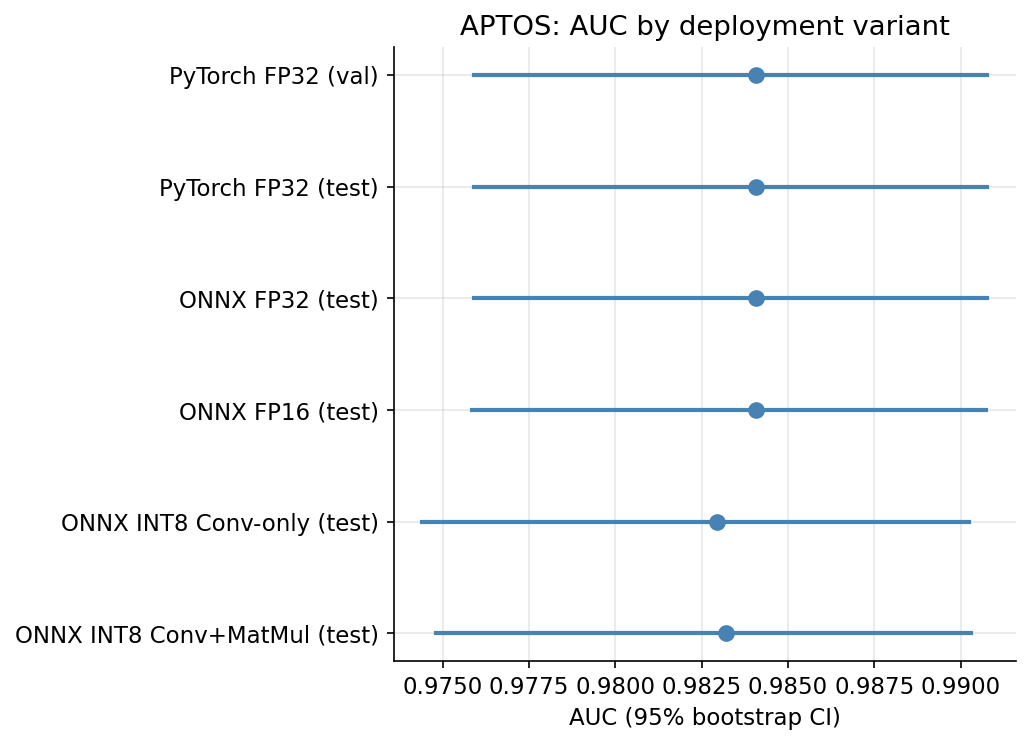

In [35]:
# ── Bootstrap 95% CIs for AUC / F1 / Sensitivity / Specificity ──────────────
# Computes CIs for every prediction-array variant that exists in this run
# (PyTorch FP32, ONNX FP32/INT8/Gen-4, ...), so it works regardless of how
# much of the notebook above has actually been executed.
import matplotlib.pyplot as plt

def calculate_metrics_with_ci(y_true, y_prob, threshold=0.5, n_bootstraps=1000, alpha=0.95, seed=0):
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    rng_local = np.random.default_rng(seed)

    boot = {'auc': [], 'f1': [], 'sens': [], 'spec': []}
    n = len(y_true)
    for _ in range(n_bootstraps):
        idx = rng_local.integers(0, n, n)
        yt, yp, ypred = y_true[idx], y_prob[idx], y_pred[idx]
        if len(np.unique(yt)) < 2:
            continue
        boot['auc'].append(roc_auc_score(yt, yp))
        boot['f1'].append(f1_score(yt, ypred, zero_division=0))
        tn, fp, fn, tp = confusion_matrix(yt, ypred, labels=[0, 1]).ravel()
        boot['sens'].append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        boot['spec'].append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    point = {
        'auc':  roc_auc_score(y_true, y_prob),
        'f1':   f1_score(y_true, y_pred, zero_division=0),
        'sens': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        'spec': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    }

    p_lo, p_hi = ((1 - alpha) / 2) * 100, (alpha + (1 - alpha) / 2) * 100
    ci = {}
    for k in point:
        boots = boot[{'auc': 'auc', 'f1': 'f1', 'sens': 'sens', 'spec': 'spec'}[k]]
        lo, hi = (np.percentile(boots, p_lo), np.percentile(boots, p_hi)) if boots else (np.nan, np.nan)
        ci[k] = (lo, hi)

    print(f"{'Metric':<15} | {'Value':<10} | {'95% CI'}")
    print("-" * 50)
    for k, label in [('auc', 'AUC'), ('f1', 'F1'), ('sens', 'Sensitivity'), ('spec', 'Specificity')]:
        lo, hi = ci[k]
        print(f"{label:<15} | {point[k]:<10.4f} | ({lo:.4f} - {hi:.4f})")

    return {'point': point, 'ci': ci}


# Candidate (label, results-dict) pairs. Only ones that actually exist in
# this run's namespace are used.
candidate_vars = [
    ('PyTorch FP32 (val)',   'fp32_val'),
    ('PyTorch FP32 (test)',  'fp32_test'),
    ('ONNX FP32 (test)',     'onnx_fp32_test'),
    ('ONNX FP16 (test)',     'onnx_fp16_test'),
    ('ONNX INT8 Conv-only (test)',    'onnx_int8_test'),
    ('ONNX INT8 Conv+MatMul (test)',  'gen4_test'),
]

forest_rows = []
for label, varname in candidate_vars:
    result = globals().get(varname)
    if not isinstance(result, dict) or 'probs' not in result or 'labels' not in result:
        continue
    print(f"\n=== {label} — {DATASET_CHOICE} ===")
    out = calculate_metrics_with_ci(result['labels'], result['probs'])
    forest_rows.append({'variant': label, **out['point'],
                         'auc_lo': out['ci']['auc'][0], 'auc_hi': out['ci']['auc'][1]})

if forest_rows:
    forest_df = pd.DataFrame(forest_rows)
    forest_out_path = os.path.join(OUT_DIR, f'forest_plot_ci_{DATASET_CHOICE.lower()}.csv')
    forest_df.to_csv(forest_out_path, index=False)
    print(f"\n\u2713 Saved CI table to {forest_out_path}")

    # ── Fig 3-style forest plot: AUC point estimate + 95% CI per variant ────
    fig, ax = plt.subplots(figsize=(7, 0.6 * len(forest_df) + 1.5))
    ys = np.arange(len(forest_df))[::-1]
    for y, row in zip(ys, forest_df.itertuples()):
        ax.plot([row.auc_lo, row.auc_hi], [y, y], color='steelblue', lw=2)
        ax.plot(row.auc, y, 'o', color='steelblue', markersize=7)
    ax.set_yticks(ys)
    ax.set_yticklabels(forest_df['variant'])
    ax.set_xlabel('AUC (95% bootstrap CI)')
    ax.set_title(f'{DATASET_CHOICE}: AUC by deployment variant')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'forest_plot_{DATASET_CHOICE.lower()}.png'), dpi=150)
    plt.show()
else:
    print("No evaluated variants found yet in this session — run the FP32/INT8 "
          "evaluation cells above first, then re-run this cell.")
